# Setup

In [1]:
!pip install torchsummary
!pip install torchmetrics
!pip install git+https://github.com/fangwei123456/spikingjelly.git

  Cloning https://github.com/fangwei123456/spikingjelly.git to /tmp/pip-req-build-y03u4h63
  Running command git clone --filter=blob:none --quiet https://github.com/fangwei123456/spikingjelly.git /tmp/pip-req-build-y03u4h63
  Resolved https://github.com/fangwei123456/spikingjelly.git to commit 1ab70215287b6bb89fcd8e7b1a27133db73134b9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 1.8 MB/s eta 0:00:00
  Created wheel for spikingjelly: filename=spikingjelly-2.0.0-py3-none-any.whl size=1005385 sha256=312dc73e689b77733cadf4bea2cdd65d5092b641c93b32dcb2a65d4dd33564ac
  Stored in directory: /tmp/pip-ephem-wheel-cache-hf4zzw6w/wheels/93/ab/c9/e0318e4c9feaebc1632bcc0168638a2ed5ef17340741c9ad49
Successfully built spikingjelly


In [2]:
%matplotlib inline

# import
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision
import numpy as np
from torchsummary import summary # Libraries for previewing neural network architectures
from spikingjelly.activation_based import neuron, encoding, functional, surrogate
from spikingjelly import visualizing
from matplotlib import pyplot as plt
import time

In [3]:
import os, re, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch.optim import Optimizer, Adam, AdamW, SGD
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import timm
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import  ImageFolder
from collections import Counter
from torchvision.transforms import ToTensor
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score


In [4]:
!python -m pip uninstall -y snn-bench


In [5]:
!pip install snn-bench --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 2.2 MB/s eta 0:00:00a 0:00:01


In [6]:
import snn_bench
from snn_bench import models, config

In [7]:
train_loader, val_loader, test_loader, meta = snn_bench.data.get_loaders(name='fashionmnist')

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 303kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.35MB/s]


In [8]:
train_loader.dataset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [9]:
train_dataset, val_dataset, test_dataset = train_loader.dataset, val_loader.dataset, test_loader.dataset

In [10]:
NUM_CLASSES  = meta.num_classes
CLASS_NAMES  = train_loader.dataset.classes
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes (10): ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Train: 60000 | Val: 5000 | Test: 5000


In [11]:
cfg = config.Config(NUM_CLASSES, CLASS_NAMES, "./model_save/checkpoints")

# ANN

In [12]:
ann = models.ann.ANN(NUM_CLASSES)


In [13]:
from snn_bench.train import train_ann



  Training: ANN

  Training from scratch: no backbone(base_model) to freeze


  Epoch 1/30 | train_loss=1.8862 | train_acc=0.5010 | val=1.3691 | val_acc=0.629
{'epoch': 1, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 1.8862210512161255, 'train_acc': 0.5010349750518799, 'val_loss': 1.369134783744812, 'val_acc': 0.6294000148773193, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 2/30 | train_loss=1.2788 | train_acc=0.6638 | val=1.1623 | val_acc=0.724
{'epoch': 2, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 1.2787901163101196, 'train_acc': 0.6638121008872986, 'val_loss': 1.1623224020004272, 'val_acc': 0.724399983882904, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 3/30 | train_loss=1.1430 | train_acc=0.7247 | val=1.0826 | val_acc=0.744
{'epoch': 3, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 1.1429940462112427, 'train_acc': 0.7247262001037598, 'val_loss': 1.082608938217163, 'val_acc': 0.7441999912261963, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 4/30 | train_loss=1.0730 | train_acc=0.7503 | val=1.0351 | val_acc=0.763
{'epoch': 4, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 1.0729954242706299, 'train_acc': 0.7502837777137756, 'val_loss': 1.03513503074646, 'val_acc': 0.7626000046730042, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


...

  Epoch 26/30 | train_loss=0.8159 | train_acc=0.8666 | val=0.8143 | val_acc=0.862
{'epoch': 26, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.8158763647079468, 'train_acc': 0.8665698170661926, 'val_loss': 0.8142743110656738, 'val_acc': 0.8618000149726868, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 27/30 | train_loss=0.8132 | train_acc=0.8662 | val=0.8113 | val_acc=0.865
{'epoch': 27, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.8131985664367676, 'train_acc': 0.8661525249481201, 'val_loss': 0.8113356232643127, 'val_acc': 0.8646000027656555, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 28/30 | train_loss=0.8103 | train_acc=0.8682 | val=0.8070 | val_acc=0.867
{'epoch': 28, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.8102726340293884, 'train_acc': 0.8682224750518799, 'val_loss': 0.8070302605628967, 'val_acc': 0.8672000169754028, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 29/30 | train_loss=0.8054 | train_acc=0.8694 | val=0.8095 | val_acc=0.864
{'epoch': 29, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.8053670525550842, 'train_acc': 0.8694244027137756, 'val_loss': 0.8094990849494934, 'val_acc': 0.8636000156402588, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  No improvement (1/5)


  Epoch 30/30 | train_loss=0.8027 | train_acc=0.8706 | val=0.8030 | val_acc=0.869
{'epoch': 30, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.802715003490448, 'train_acc': 0.8706096410751343, 'val_loss': 0.8030049800872803, 'val_acc': 0.8690000176429749, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved
  ✔✔ Best checkpoint loaded: val_loss=0.8030


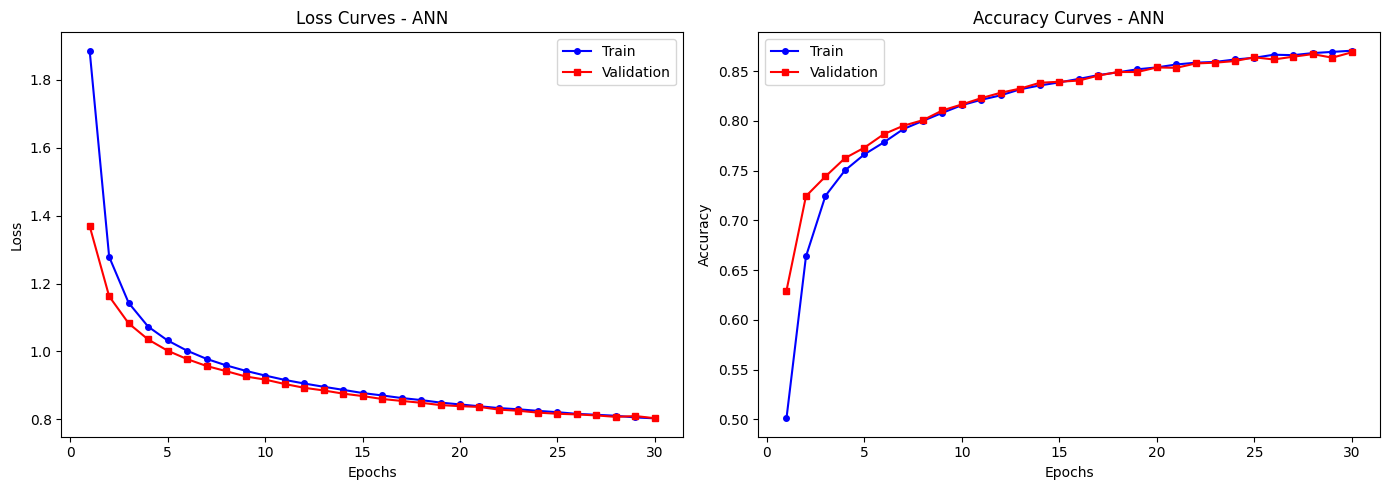


───────────────────────────────────────────────────────
  ANN
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

 T-shirt/top      0.776     0.821     0.798       481
     Trouser      0.989     0.977     0.983       473
    Pullover      0.808     0.773     0.790       507
       Dress      0.854     0.895     0.874       524
        Coat      0.767     0.786     0.776       501
      Sandal      0.965     0.935     0.950       496
       Shirt      0.660     0.600     0.629       515
     Sneaker      0.913     0.934     0.923       497
         Bag      0.955     0.965     0.960       511
  Ankle boot      0.942     0.958     0.950       495

    accuracy                          0.863      5000
   macro avg      0.863     0.864     0.863      5000
weighted avg      0.862     0.863     0.862      5000

  Macro F1: 0.8634

  Confusion Matrix: tensor([[395,   0,   6,  26,   3,   1,  44,   0,   6,   0],
        [  0, 462,   1

In [14]:
#options = train_ann.TrainOptions.get_default()

ann_history_results, ann_evaluation_results, ann_results = train_ann.start_training_ann_loop(ann, train_loader, val_loader, test_loader, cfg)

In [15]:
from snn_bench.evaluate import eval_ann


  Confusion Matrix: ANN


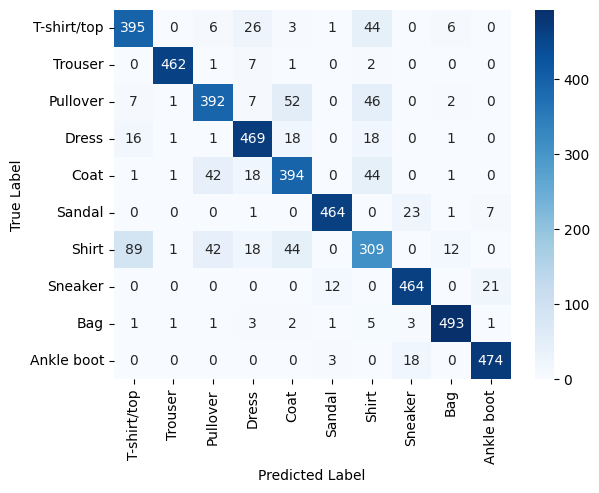

In [16]:
for model_name, er in ann_evaluation_results.items():
  print(f"\n{'='*60}")
  print(f"  Confusion Matrix: {model_name}")
  print(f"{'='*60}")
  eval_ann.plot_confusion_matrix(er, model_name, cfg)


True label: 1
Predicted label: 1


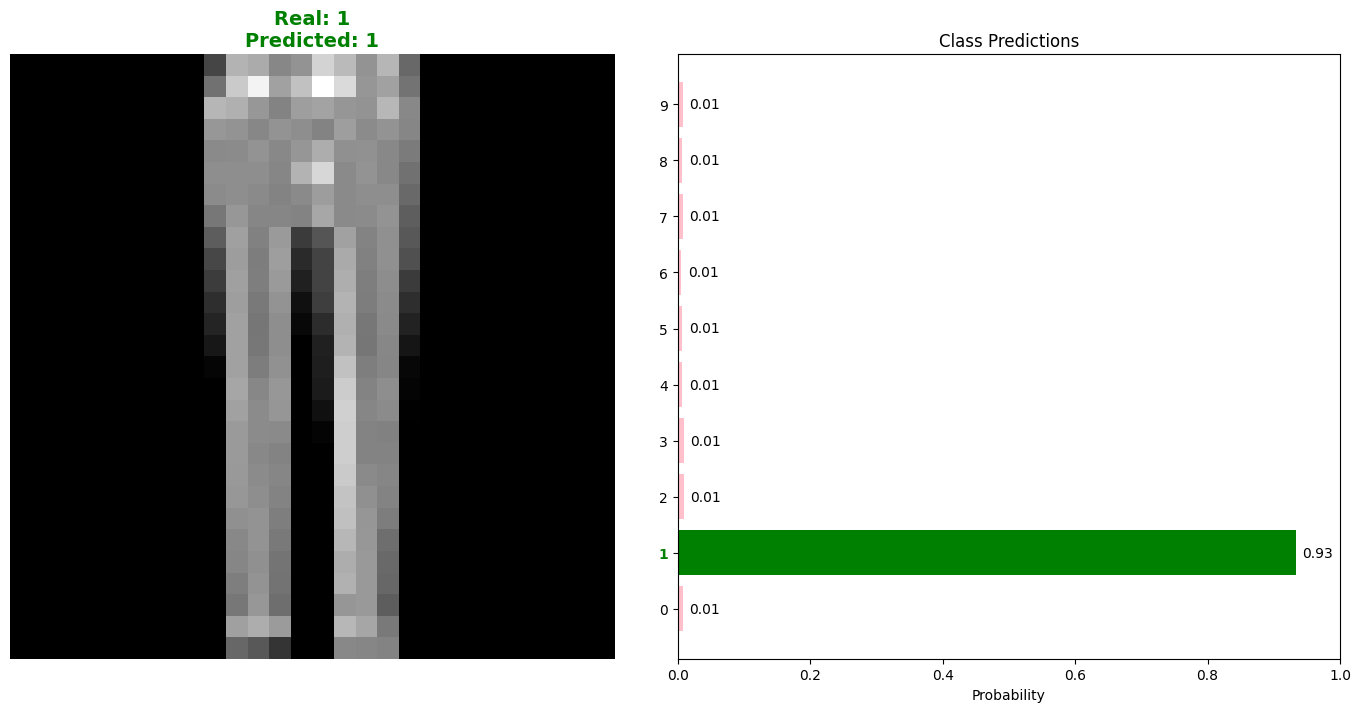

In [17]:
eval_ann.test_eval(ann, 4373, test_dataset, cfg)

# SNN

In [18]:
snn = models.snn.SNN()
snn.to(cfg.device)

SNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_1): Linear(in_features=784, out_features=10, bias=False)
  (lif_layer_1): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
)

In [19]:
from snn_bench.train import train_snn

In [20]:
snn_options = train_snn.TrainOptions.get_default_none()

loss_train_store, loss_cv_store, accuracy_rate_train_store, accuracy_rate_cv_store, epoch = train_snn.start_training_snn_loop(snn, train_loader, test_loader, cfg, snn_options)

----------- 0 round of training begins------------
loss train:  0.0406, accuracy rate train:  75.7033%, loss cv:  0.0342, accuracy rate cv:  79.6000%
----------- 1 round of training begins------------
loss train:  0.0304, accuracy rate train:  82.4533%, loss cv:  0.0318, accuracy rate cv:  81.3800%
----------- 2 round of training begins------------
loss train:  0.0282, accuracy rate train:  83.5283%, loss cv:  0.0303, accuracy rate cv:  82.2800%
----------- 3 round of training begins------------
loss train:  0.0272, accuracy rate train:  83.9717%, loss cv:  0.0289, accuracy rate cv:  83.3800%
----------- 4 round of training begins------------
loss train:  0.0266, accuracy rate train:  84.2450%, loss cv:  0.0292, accuracy rate cv:  82.7800%
-------------------------------Training Complete-------------------------------


In [21]:
from snn_bench.evaluate import eval_snn

---------Graph showing how the loss function changes over training epochs---------


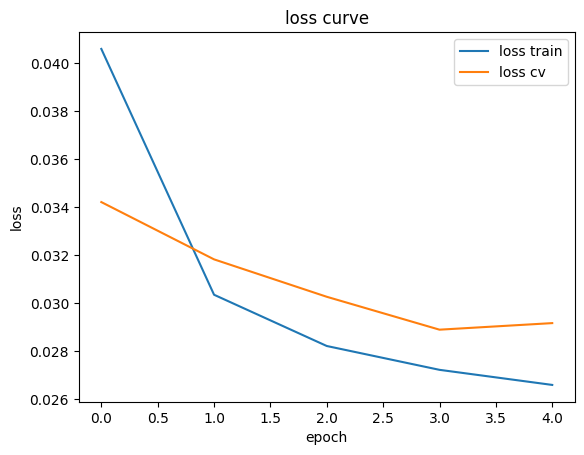

---------Graph showing how accuracy changes over training epochs---------


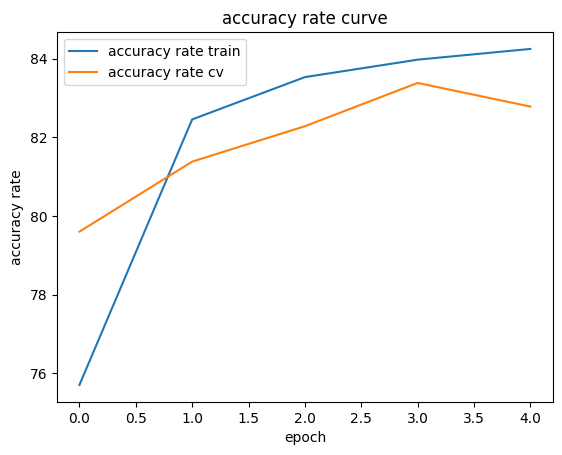

In [22]:
eval_snn.plot_loss_curves(epoch, loss_train_store, loss_cv_store, accuracy_rate_train_store, accuracy_rate_cv_store)

Original image
label: 6


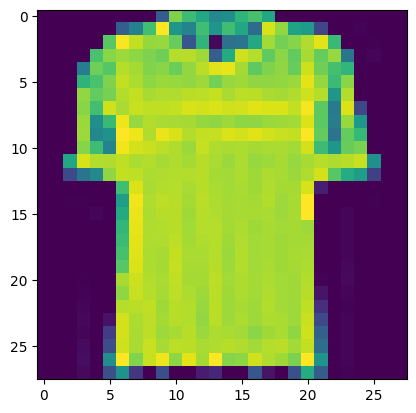

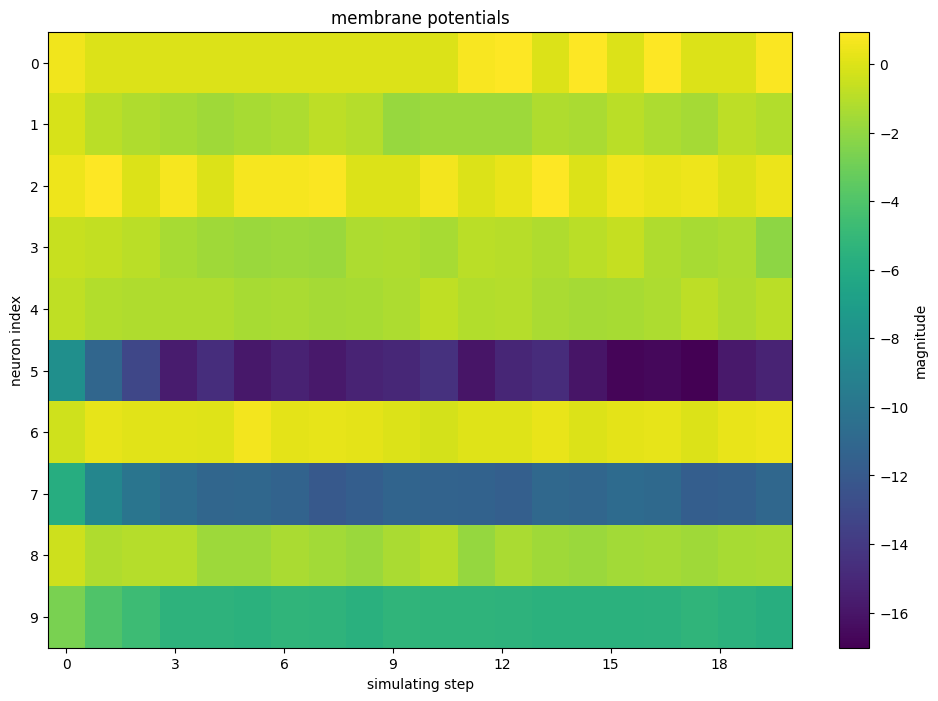

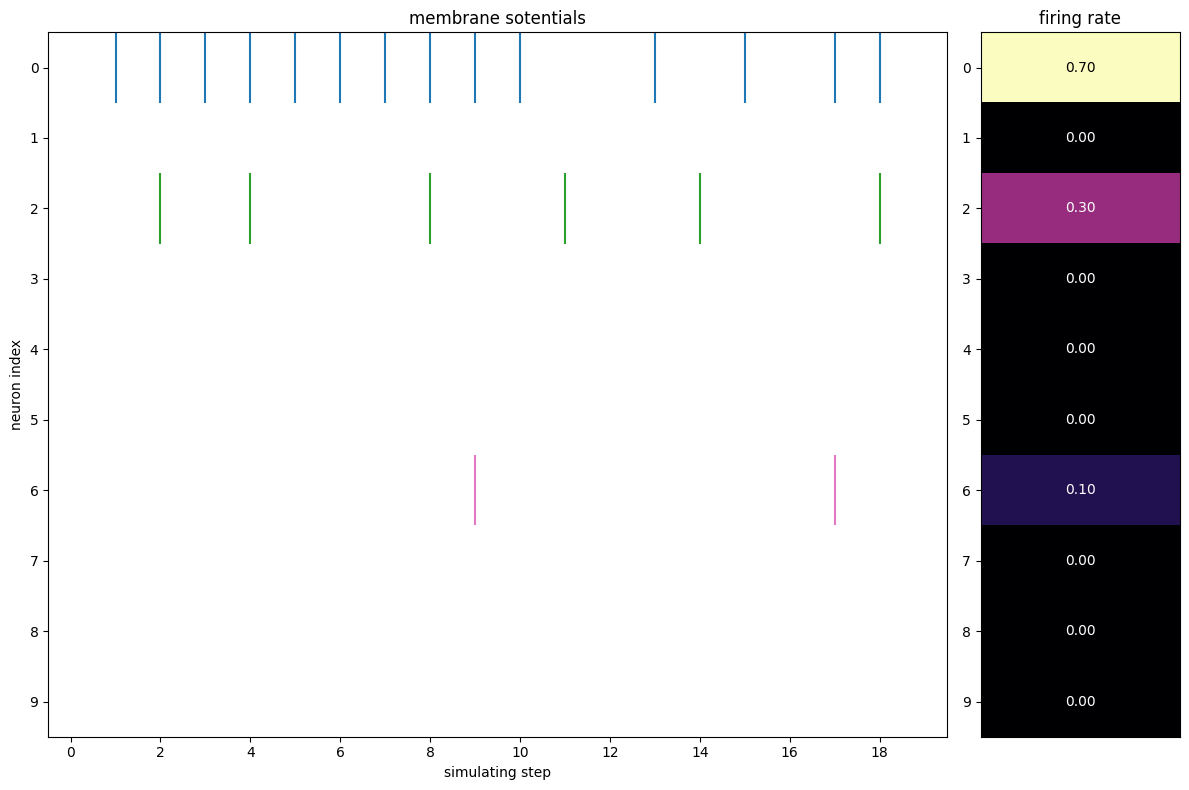

In [23]:
#For a more intuitive understanding, we can select a single image for prediction; by changing the index, we can choose different input images.

# Obtaining the membrane potential of the output layer neurons at this point is somewhat challenging and requires the use of the “hook” feature.

# Retrieve a single image for prediction

# Load the raw data
# Load a single image from the test set
# Save the data for plotting
snn.eval()
functional.reset_net(snn)
# Register a hook
output_layer = snn.lif_layer_1 # Output layer
output_layer.v_seq = []
output_layer.s_seq = []
def save_hook(m, x, y):
    m.v_seq.append(m.v.unsqueeze(0))
    m.s_seq.append(y.unsqueeze(0))

hook = output_layer.register_forward_hook(save_hook)

# Load a single image from the test set
index = 3373
input, label = test_dataset[index]
input = torchvision.transforms.ToPILImage()(input)
plt.imshow(input)
print('Original image')
print(f"label: {label}")
plt.show()

encoder = snn_options = train_snn.TrainOptions.get_default().encoder
T = 20
# Start making predictions with the neural network
snn.eval()

with torch.no_grad():
    img, label = test_dataset[index]
    img = img.unsqueeze(0).to(cfg.device)
    out_fr = 0.
    for t in range(T):
        encoded_img = encoder(img)
        out_fr += snn(encoded_img)
    out_spikes_counter_frequency = (out_fr / T).cpu().numpy()

    output_layer.v_seq = torch.cat(output_layer.v_seq)
    output_layer.s_seq = torch.cat(output_layer.s_seq)
    v_t_array = output_layer.v_seq.cpu().numpy().squeeze()  # v_t_array[i][j] represents the voltage value of neuron i at time j
    s_t_array = output_layer.s_seq.cpu().numpy().squeeze()  # s_t_array[i][j] represents the spike fired by neuron i at time j, which is either 0 or 1

    # Heatmap of membrane potentials and spike output results
    figsize = (12, 8)
    dpi = 100
    visualizing.plot_2d_heatmap(array=v_t_array, title='membrane potentials', xlabel='simulating step',
                                ylabel='neuron index', int_x_ticks=True, x_max=T, figsize=figsize, dpi=dpi)
    visualizing.plot_1d_spikes(spikes=s_t_array, title='membrane sotentials', xlabel='simulating step',
                            ylabel='neuron index', figsize=figsize, dpi=dpi)

    plt.show()

hook.remove()

In [24]:
snn = models.snn.DirectSNN(NUM_CLASSES)
snn.to(cfg.device)

DirectSNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (1): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (4): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1, step_mode=s)
    (1): Linear(in_features=3136, out_features=512, bias=False)
    (2): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=Fals

In [25]:
snn_options = train_snn.TrainOptions.get_default_none()

loss_train_store, loss_cv_store, accuracy_rate_train_store, accuracy_rate_cv_store, epoch = train_snn.start_training_snn_loop(snn, train_loader, test_loader, cfg, snn_options)

----------- 0 round of training begins------------
loss train:  0.0506, accuracy rate train:  59.3017%, loss cv:  0.0287, accuracy rate cv:  80.0200%
----------- 1 round of training begins------------
loss train:  0.0237, accuracy rate train:  83.5400%, loss cv:  0.0234, accuracy rate cv:  84.1400%
----------- 2 round of training begins------------
loss train:  0.0199, accuracy rate train:  86.2967%, loss cv:  0.0208, accuracy rate cv:  85.8800%
----------- 3 round of training begins------------
loss train:  0.0180, accuracy rate train:  87.6600%, loss cv:  0.0198, accuracy rate cv:  86.3000%
----------- 4 round of training begins------------
loss train:  0.0168, accuracy rate train:  88.5900%, loss cv:  0.0190, accuracy rate cv:  86.9800%
-------------------------------Training Complete-------------------------------


---------Graph showing how the loss function changes over training epochs---------


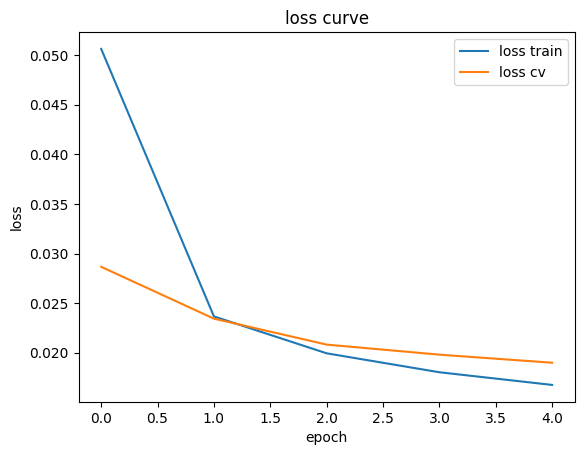

---------Graph showing how accuracy changes over training epochs---------


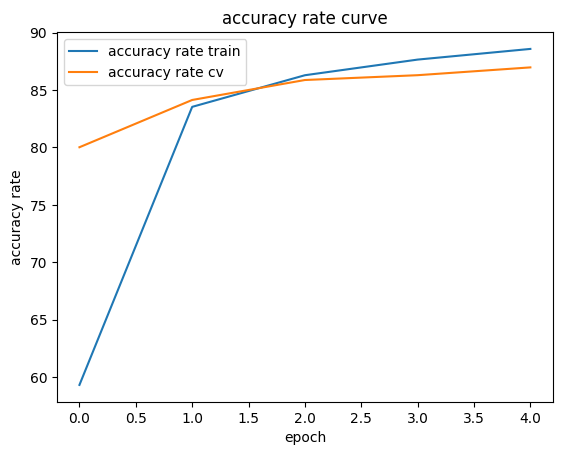

In [26]:
eval_snn.plot_loss_curves(epoch, loss_train_store, loss_cv_store, accuracy_rate_train_store, accuracy_rate_cv_store)

Original image
label: 8


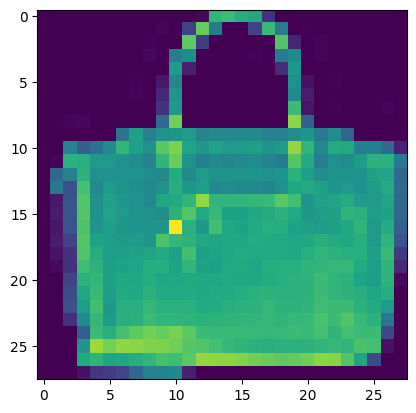

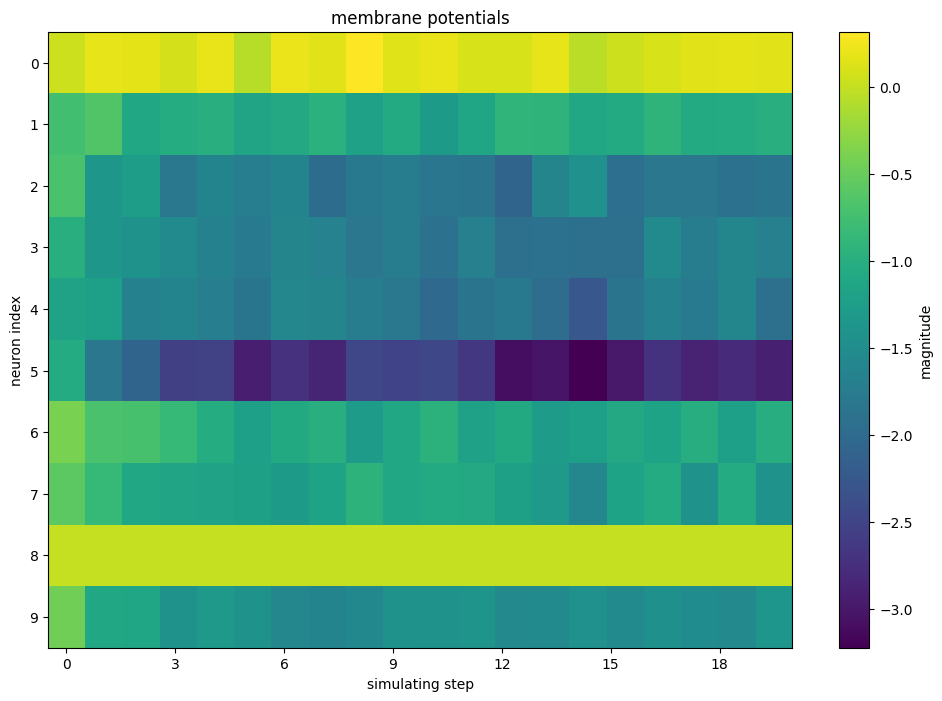

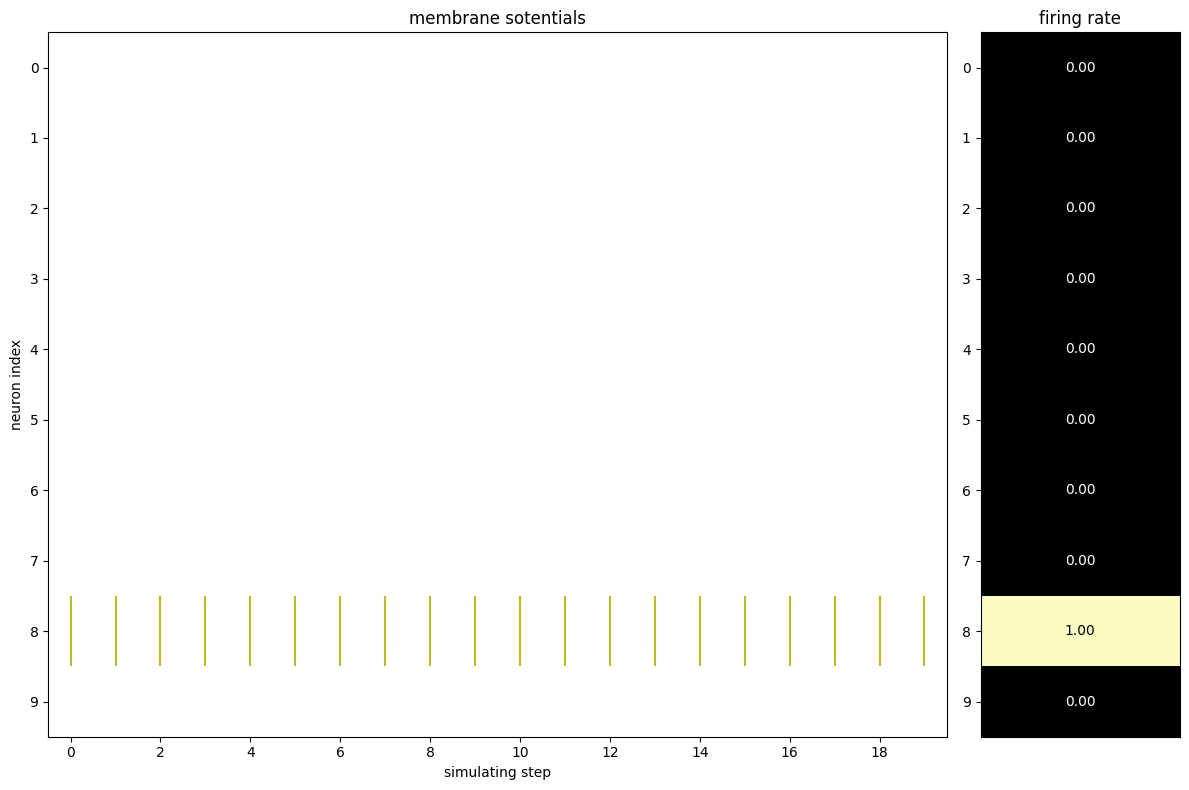

In [27]:
#For a more intuitive understanding, we can select a single image for prediction; by changing the index, we can choose different input images.

# Obtaining the membrane potential of the output layer neurons at this point is somewhat challenging and requires the use of the “hook” feature.

# Retrieve a single image for prediction

# Load the raw data
# Load a single image from the test set
# Save the data for plotting
snn.eval()
functional.reset_net(snn)
# Register a hook
output_layer = snn.classifier[6] # Output layer
output_layer.v_seq = []
output_layer.s_seq = []
def save_hook(m, x, y):
    m.v_seq.append(m.v.unsqueeze(0))
    m.s_seq.append(y.unsqueeze(0))

hook = output_layer.register_forward_hook(save_hook)

# Load a single image from the test set
index = 345
input, label = test_dataset[index]
input = torchvision.transforms.ToPILImage()(input)
plt.imshow(input)
print('Original image')
print(f"label: {label}")
plt.show()

encoder = snn_options = train_snn.TrainOptions.get_default().encoder
T = 20
# Start making predictions with the neural network
snn.eval()

with torch.no_grad():
    img, label = test_dataset[index]
    img = img.unsqueeze(0).to(cfg.device)
    out_fr = 0.
    for t in range(T):
        encoded_img = encoder(img)
        out_fr += snn(encoded_img)
    out_spikes_counter_frequency = (out_fr / T).cpu().numpy()

    output_layer.v_seq = torch.cat(output_layer.v_seq)
    output_layer.s_seq = torch.cat(output_layer.s_seq)
    v_t_array = output_layer.v_seq.cpu().numpy().squeeze()  # v_t_array[i][j] represents the voltage value of neuron i at time j
    s_t_array = output_layer.s_seq.cpu().numpy().squeeze()  # s_t_array[i][j] represents the spike fired by neuron i at time j, which is either 0 or 1

    # Heatmap of membrane potentials and spike output results
    figsize = (12, 8)
    dpi = 100
    visualizing.plot_2d_heatmap(array=v_t_array, title='membrane potentials', xlabel='simulating step',
                                ylabel='neuron index', int_x_ticks=True, x_max=T, figsize=figsize, dpi=dpi)
    visualizing.plot_1d_spikes(spikes=s_t_array, title='membrane sotentials', xlabel='simulating step',
                            ylabel='neuron index', figsize=figsize, dpi=dpi)

    plt.show()

hook.remove()

Original image
label: 6


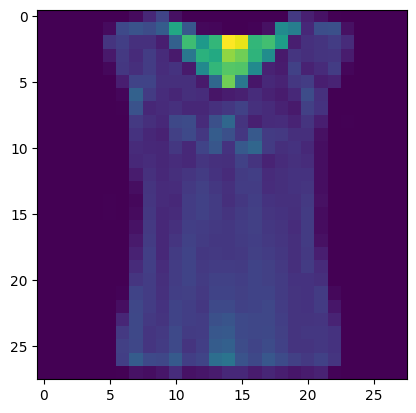

Unexpected err=RuntimeError('mat1 and mat2 shapes cannot be multiplied (64x49 and 3136x512)'), type(err)=<class 'RuntimeError'>


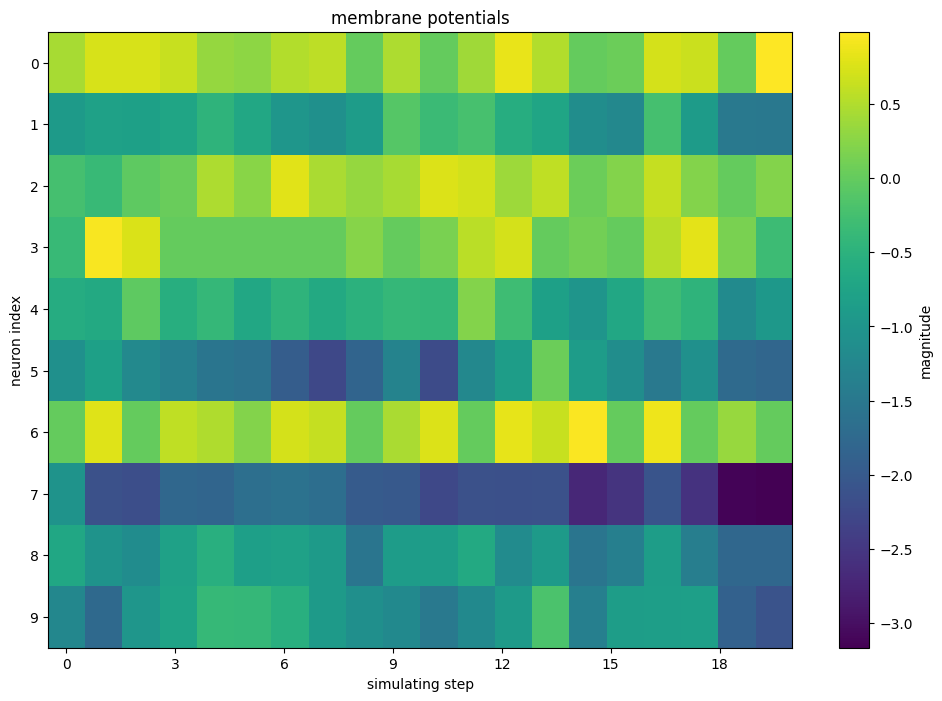

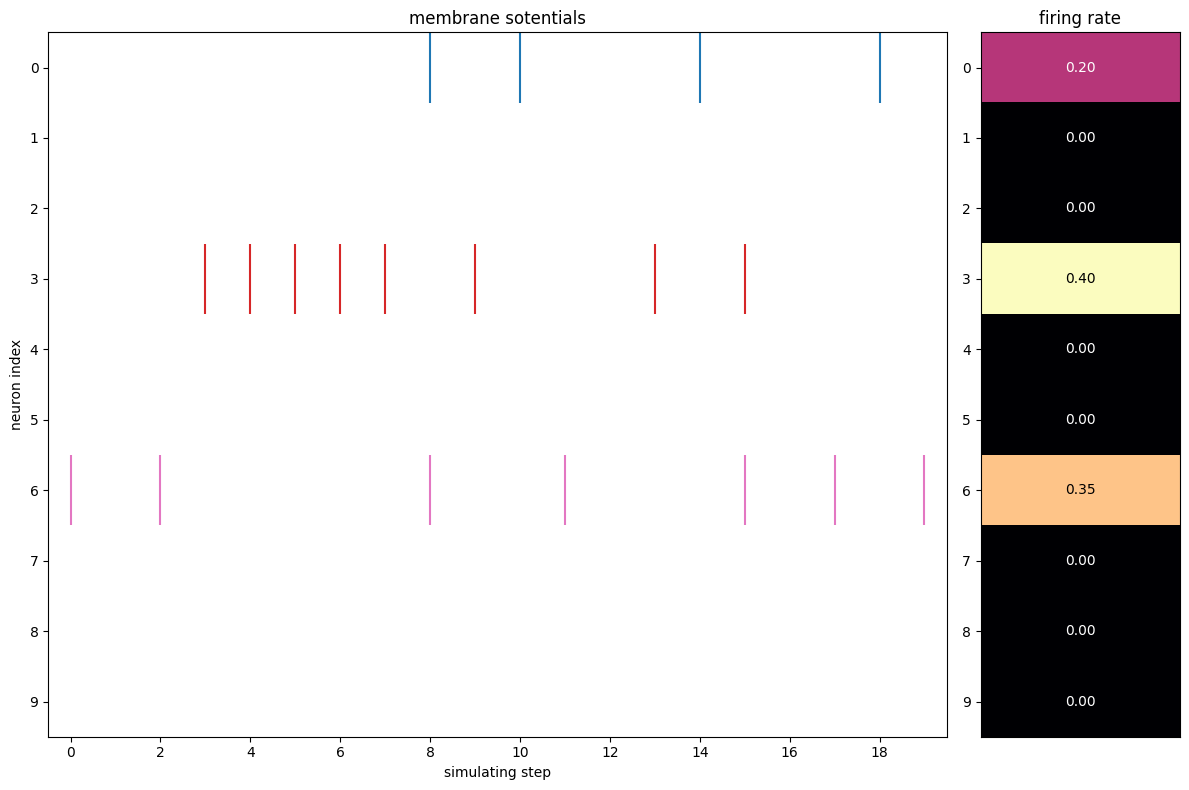

In [28]:
from spikingjelly.activation_based import neuron, encoding, functional, surrogate


eval_snn.plot_snn_module_spikes(snn, test_dataset, encoding.PoissonEncoder(), cfg, 798)

# ANN2SNN

In [29]:
from snn_bench.conversion import Converter
import snn_bench.conversion_mod.recipes as snn_bench_recipes

In [30]:
conv_snn_max = Converter.handle_rate_coded(ann, train_dataset, cfg)

100%|██████████| 469/469 [00:14<00:00, 31.88it/s]


In [31]:
conv_snn_max

GraphModule(
  (features): Module(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (spiking_0): Module(
      (scaler0): VoltageScaler(0.536225, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1): VoltageScaler(1.864889, step_mode=s)
    )
    (spiking_1): Module(
      (scaler0): VoltageScaler(0.425762, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1

In [32]:
conv_snn_99 =  Converter.handle_rate_coded(ann, train_dataset, cfg, mode="99.9%")

100%|██████████| 469/469 [00:15<00:00, 30.77it/s]


In [33]:
conv_snn_99

GraphModule(
  (features): Module(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (spiking_0): Module(
      (scaler0): VoltageScaler(0.621204, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1): VoltageScaler(1.609777, step_mode=s)
    )
    (spiking_1): Module(
      (scaler0): VoltageScaler(0.507848, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1

In [34]:
conv_snn_balanced = Converter.handle_rate_coded_threshold_balanced(ann, train_dataset, cfg)

100%|██████████| 469/469 [00:14<00:00, 32.29it/s]


In [35]:
conv_snn_half =  Converter.handle_rate_coded(ann, train_dataset, cfg, mode=1.0/2)

100%|██████████| 469/469 [00:14<00:00, 32.94it/s]


In [36]:
from snn_bench.evaluate import eval_snn

In [37]:
curve_max  = eval_snn.accuracy_vs_T(conv_snn_max,  test_loader, T_max=64, device=cfg.device)
curve_99 = eval_snn.accuracy_vs_T(conv_snn_99, test_loader, T_max=64, device=cfg.device)
curve_half = eval_snn.accuracy_vs_T(conv_snn_half, test_loader, T_max=64, device=cfg.device)
curve_balanced = eval_snn.accuracy_vs_T(conv_snn_balanced, test_loader, T_max=64, device=cfg.device)
curve_base_snn = eval_snn.accuracy_vs_T(snn, test_loader, T_max=64, device=cfg.device)

In [38]:
ann_results['ANN'].accuracy

0.8632000088691711

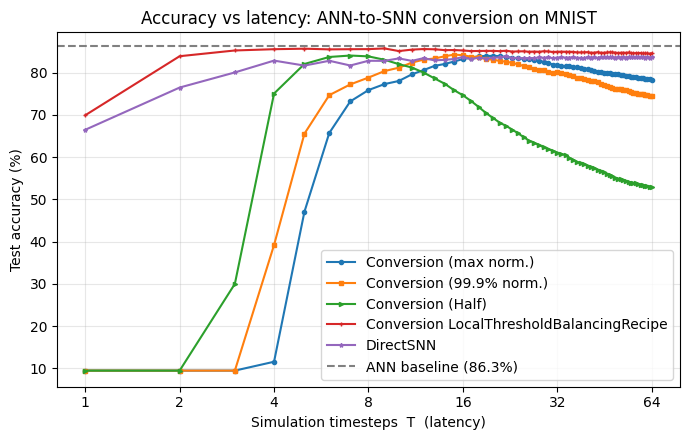

In [39]:
eval_snn.plot_accuracy_vs_T(ann_results['ANN'].accuracy, 64, [
    {"y": curve_max, "marker": "o", "ms": 3, "label": "Conversion (max norm.)"},
    {"y": curve_99,  "marker": "s", "ms": 3, "label": "Conversion (99.9% norm.)"},
    {"y": curve_half,  "marker": ">", "ms": 3, "label": "Conversion (Half)"},
    {"y": curve_balanced,  "marker": "+", "ms": 3, "label": "Conversion LocalThresholdBalancingRecipe"},
    {"y": curve_base_snn, "marker": "*", "ms": 3, "label": "DirectSNN"},
])

In [40]:
from snn_bench.conversion import eval_conv_snn

Original label: 6


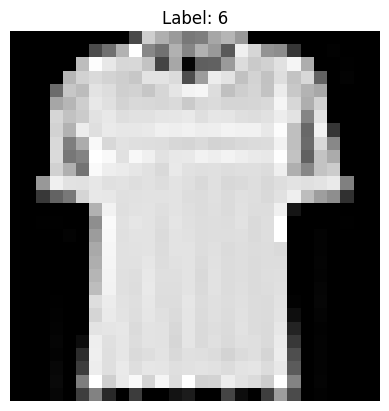

Predicted class (rate coding, T=16): 0


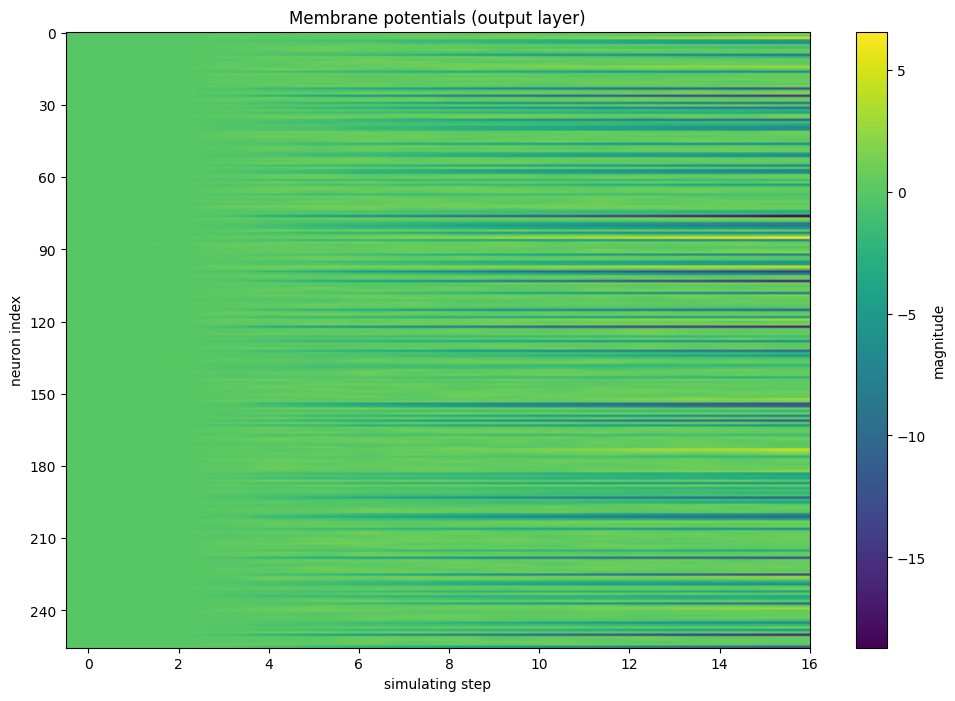

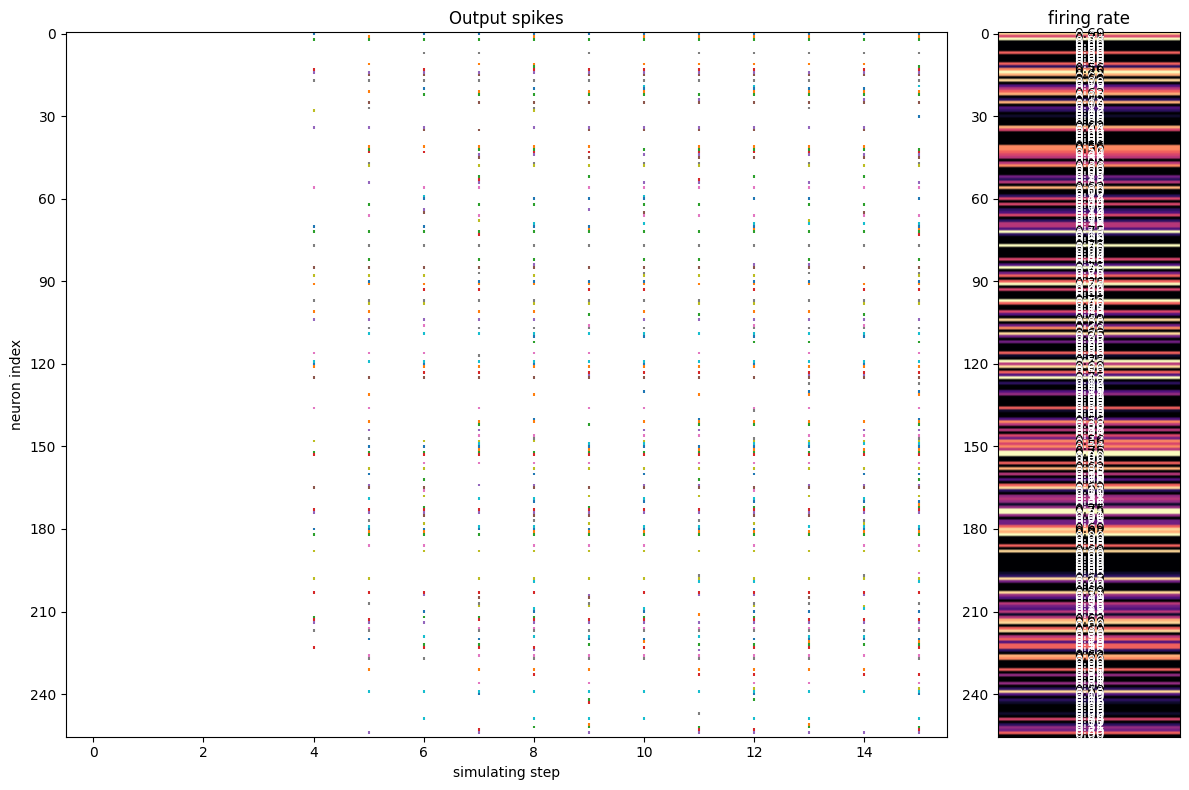

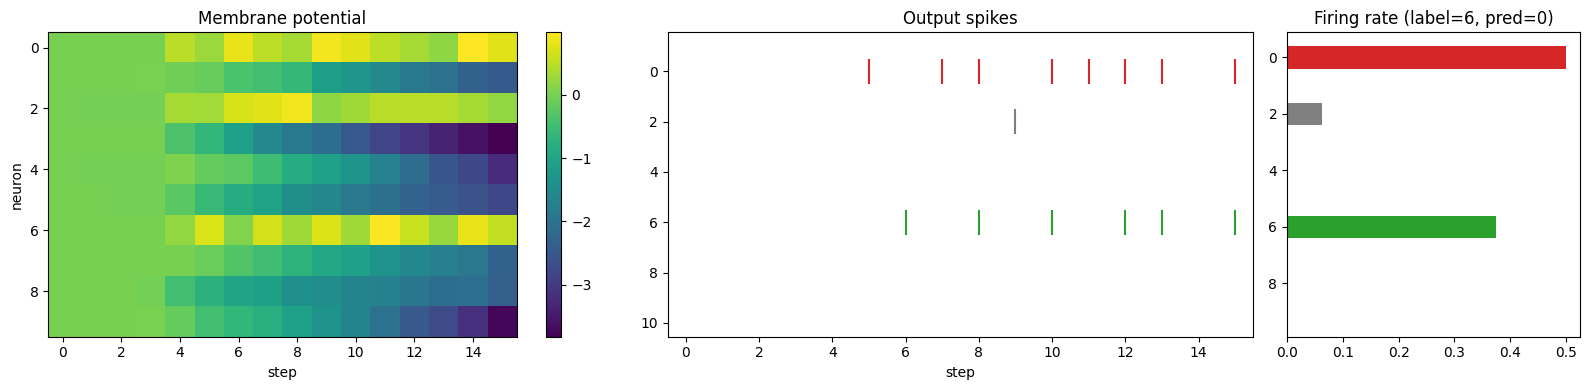

Original label: 6


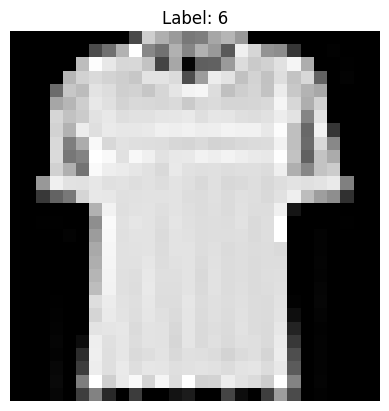

Predicted class (rate coding, T=16): 0


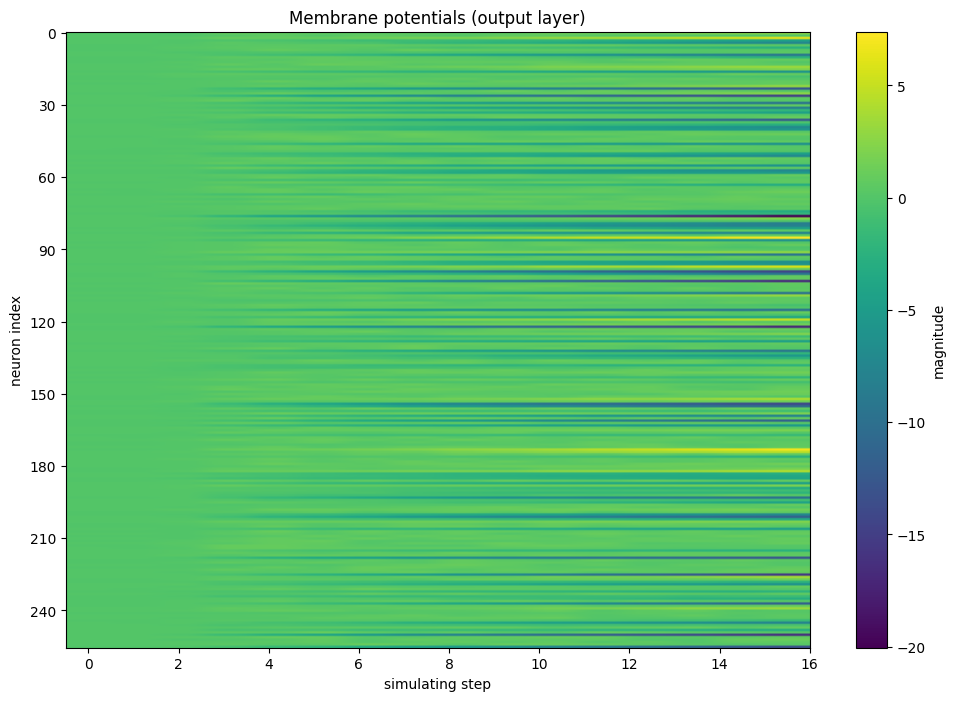

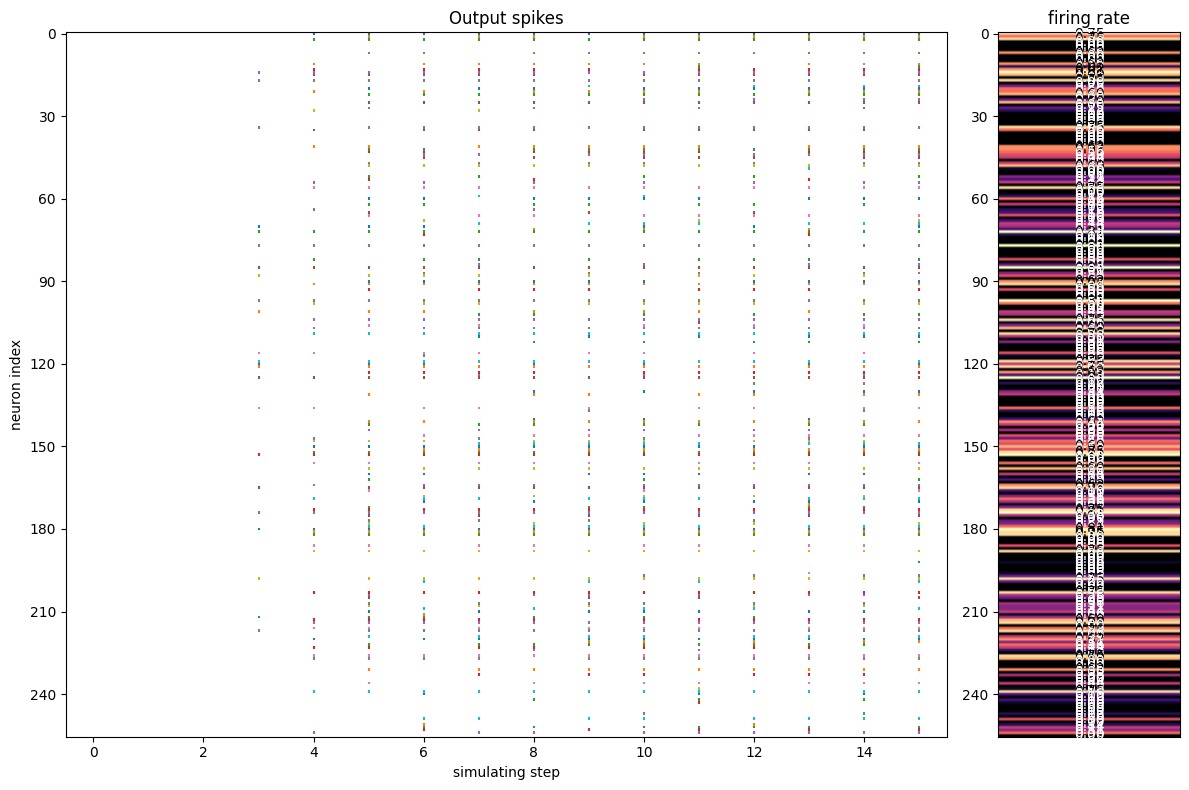

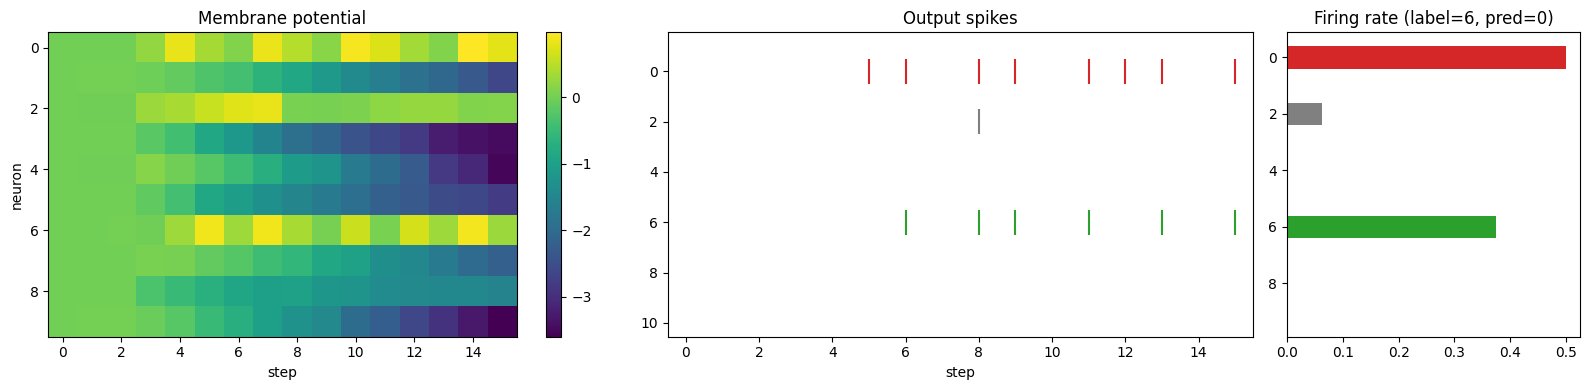

Original label: 6


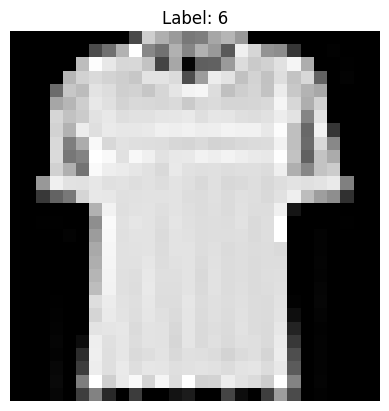

Predicted class (rate coding, T=16): 0


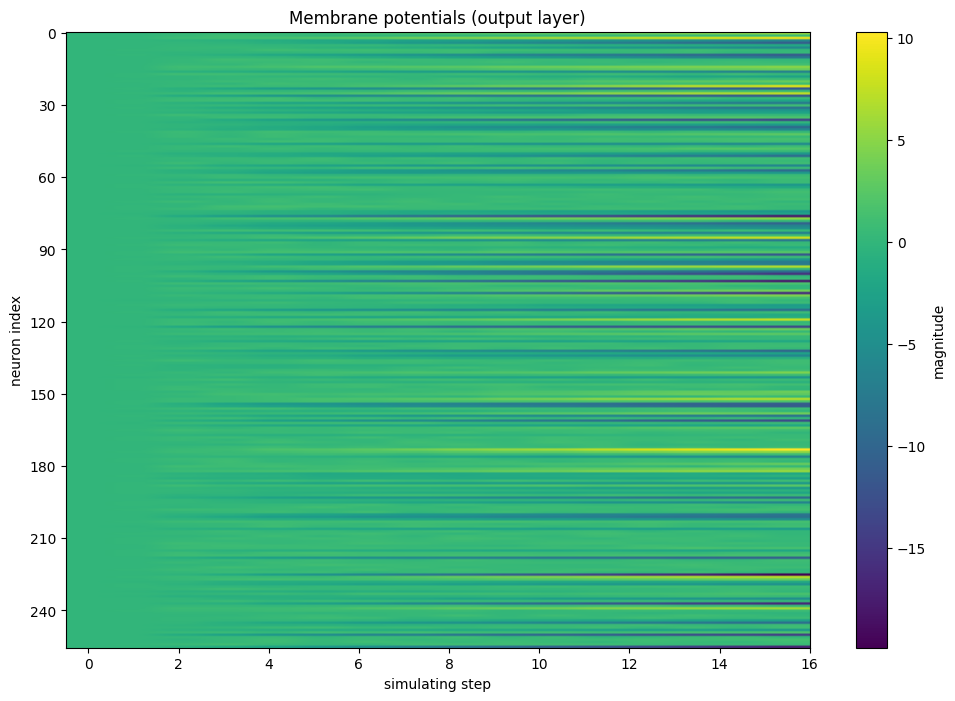

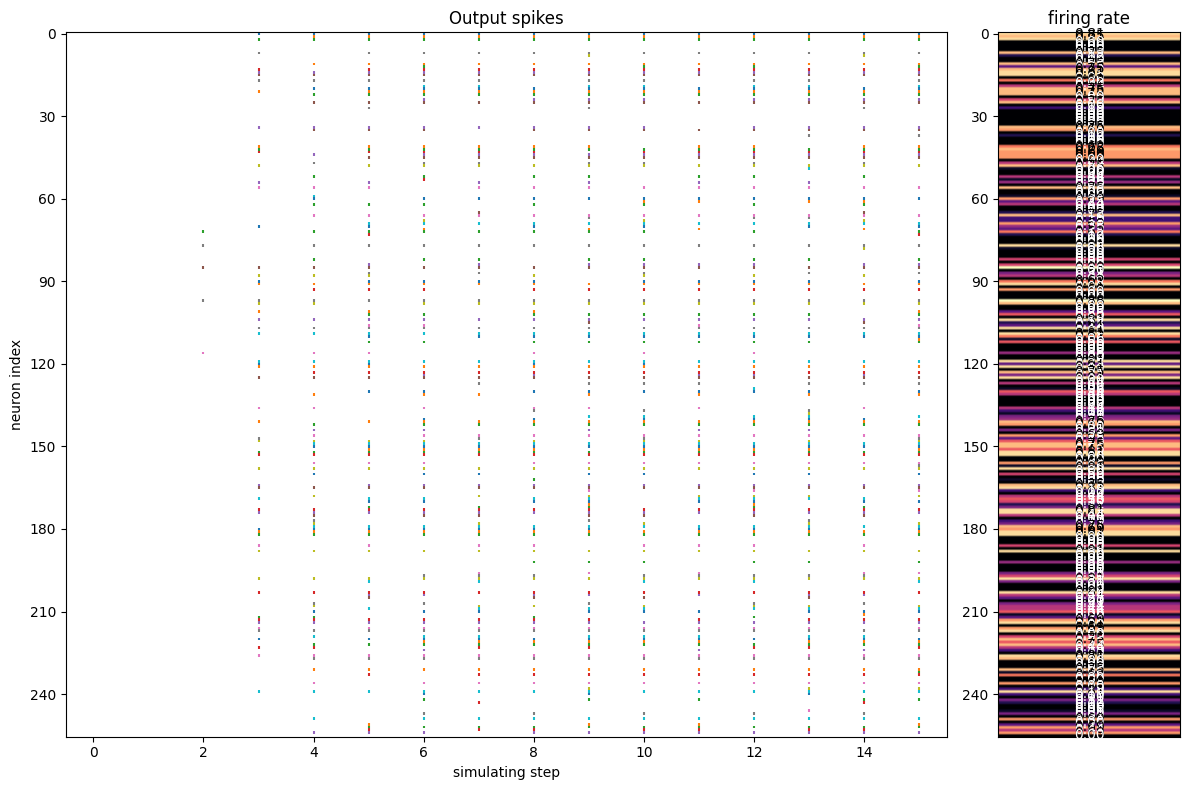

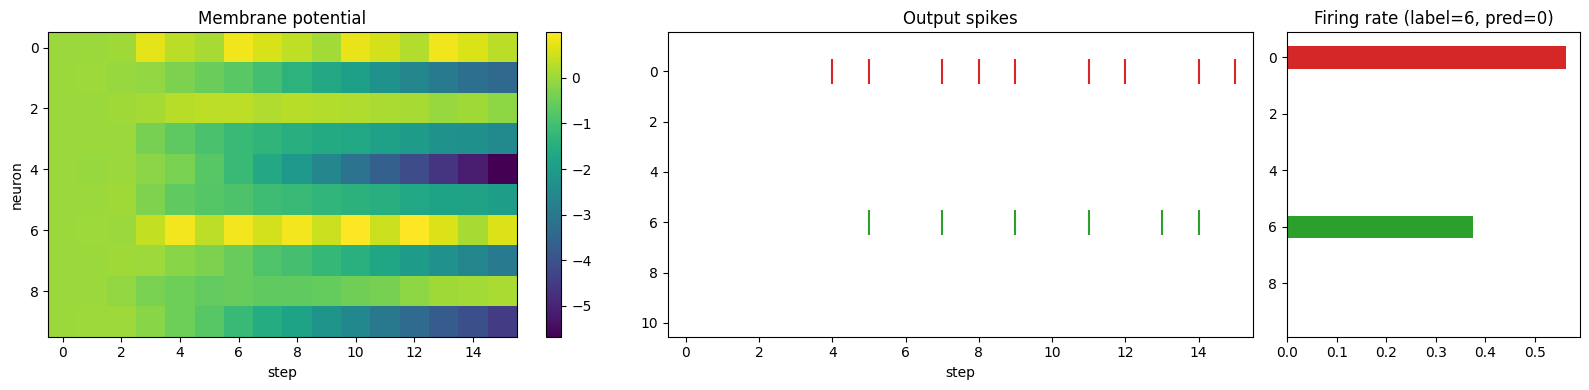

Original label: 6


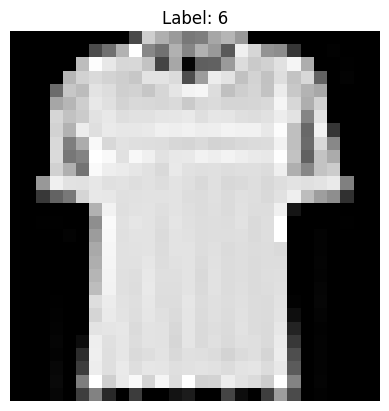

Predicted class (rate coding, T=16): 0


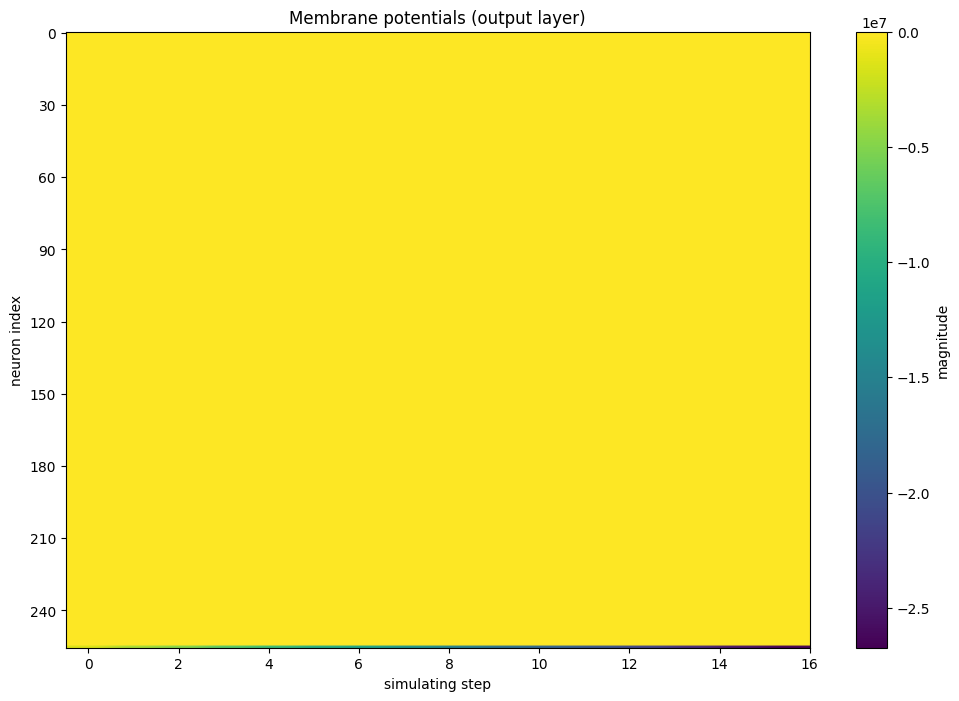

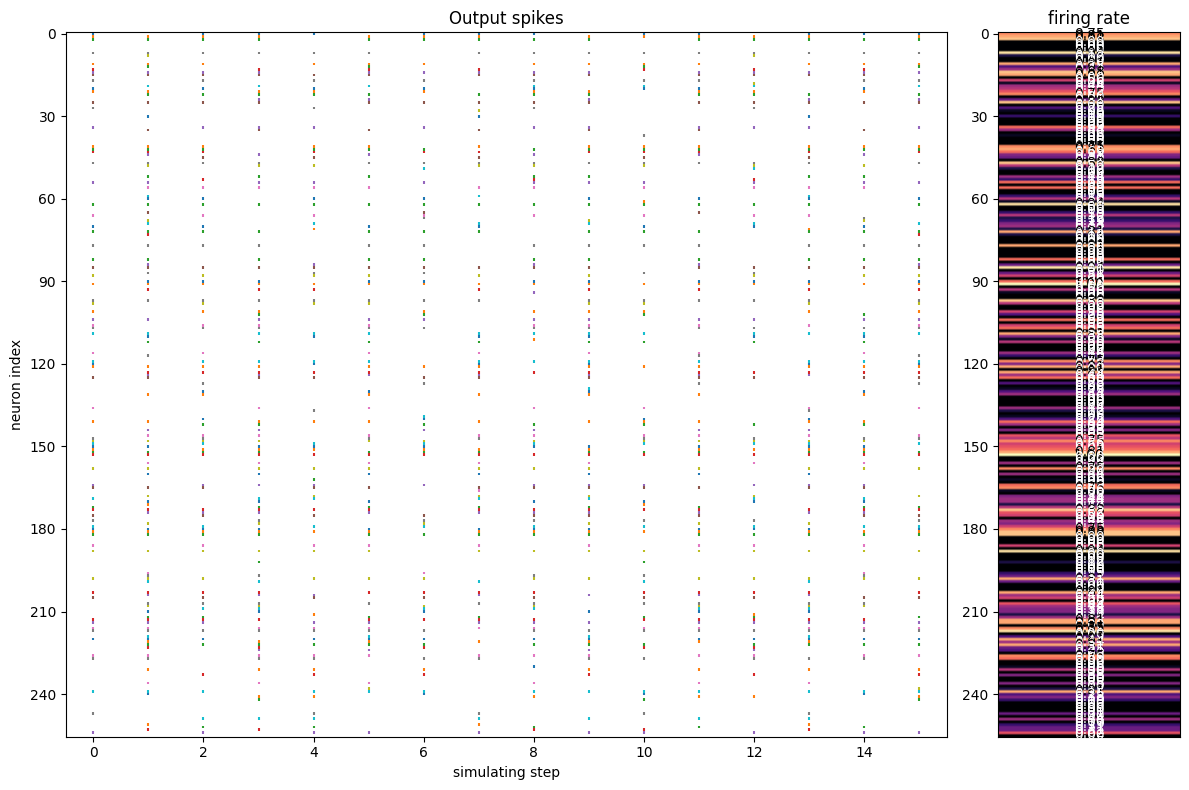

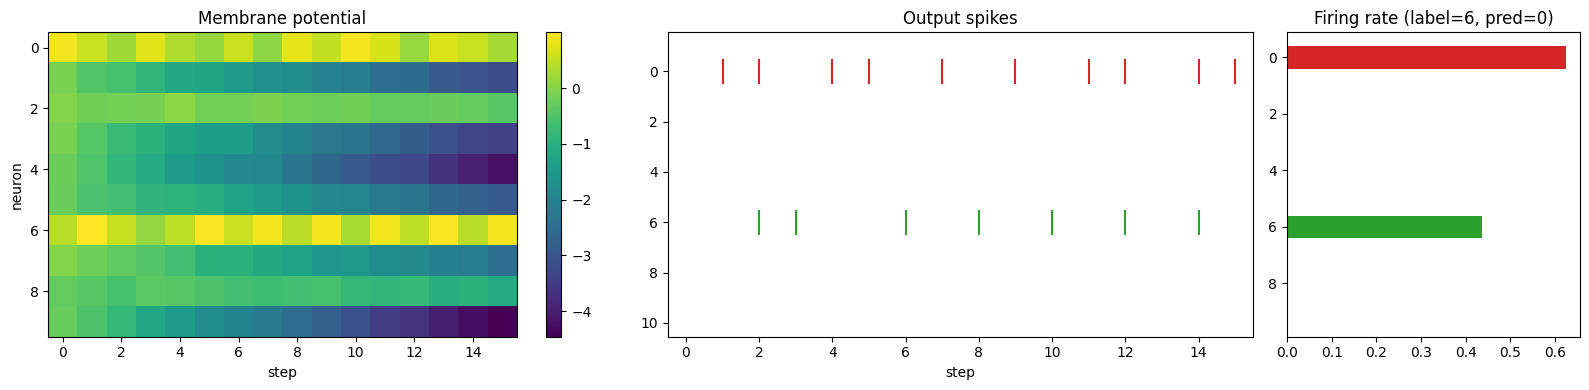

In [41]:
eval_conv_snn.try_visualize_converted(conv_snn_max, test_dataset, T=16, index=3373, device=cfg.device)
eval_conv_snn.try_visualize_converted(conv_snn_99, test_dataset, T=16, index=3373, device=cfg.device)
eval_conv_snn.try_visualize_converted(conv_snn_half, test_dataset, T=16, index=3373, device=cfg.device)
eval_conv_snn.try_visualize_converted(conv_snn_balanced, test_dataset, T=16, index=3373, device=cfg.device)

# Benchmark

In [42]:
from snn_bench.benchmark import Benchmark

In [43]:
import snn_bench.conversion_mod.recipes as snn_bench_recipes

In [44]:
import psutil
import snn_bench.bench.level3 as level3

print("Notebook psutil:", psutil)
print("level3 file:", level3.__file__)
print("level3 has psutil:", hasattr(level3, "psutil"))
print("level3 psutil:", getattr(level3, "psutil", None))


Notebook psutil: <module 'psutil' from '/usr/local/lib/python3.12/dist-packages/psutil/__init__.py'>
level3 file: /usr/local/lib/python3.12/dist-packages/snn_bench/bench/level3.py
level3 has psutil: True
level3 psutil: <module 'psutil' from '/usr/local/lib/python3.12/dist-packages/psutil/__init__.py'>


ANN baseline (int32)
  accuracy        : 0.8632
  MACs            : 5,577,728
  memory ops      : 9,496,916
  E_analytical    : 1.0945e-03 J/sample
    E_mem         : 1.0766e-03 J (98.4%)
    E_ops         : 1.7853e-05 J (1.6%)
    E_addr        : 5.0234e-09 J (0.0%)
  latency         : 0.1765 ms/sample
  GPU (marginal)  : 3.8799e-04 J/sample
  power spread    : 0.2 W across 3 trials

       layer kind     mac      rd    wr      mem_kB  pJ_per_access        E_mem        E_ops      E_total  pct_of_total
  features.0 conv  225792  476672 25088  102.312500      25.670363 1.288036e-05 7.250432e-07 1.360802e-05      1.243330
  features.3 conv 3612672 7237888 12544  145.750000      29.173387 2.115197e-04 1.156180e-05 2.230834e-04     20.382558
classifier.1   fc 1605632 1609280   512 6288.250000     524.536290 8.443943e-04 5.138074e-06 8.495328e-04     77.619629
classifier.4   fc  131072  131840   256  516.000000      59.032258 7.797925e-06 4.194560e-07 8.217458e-06      0.750808
classifier.

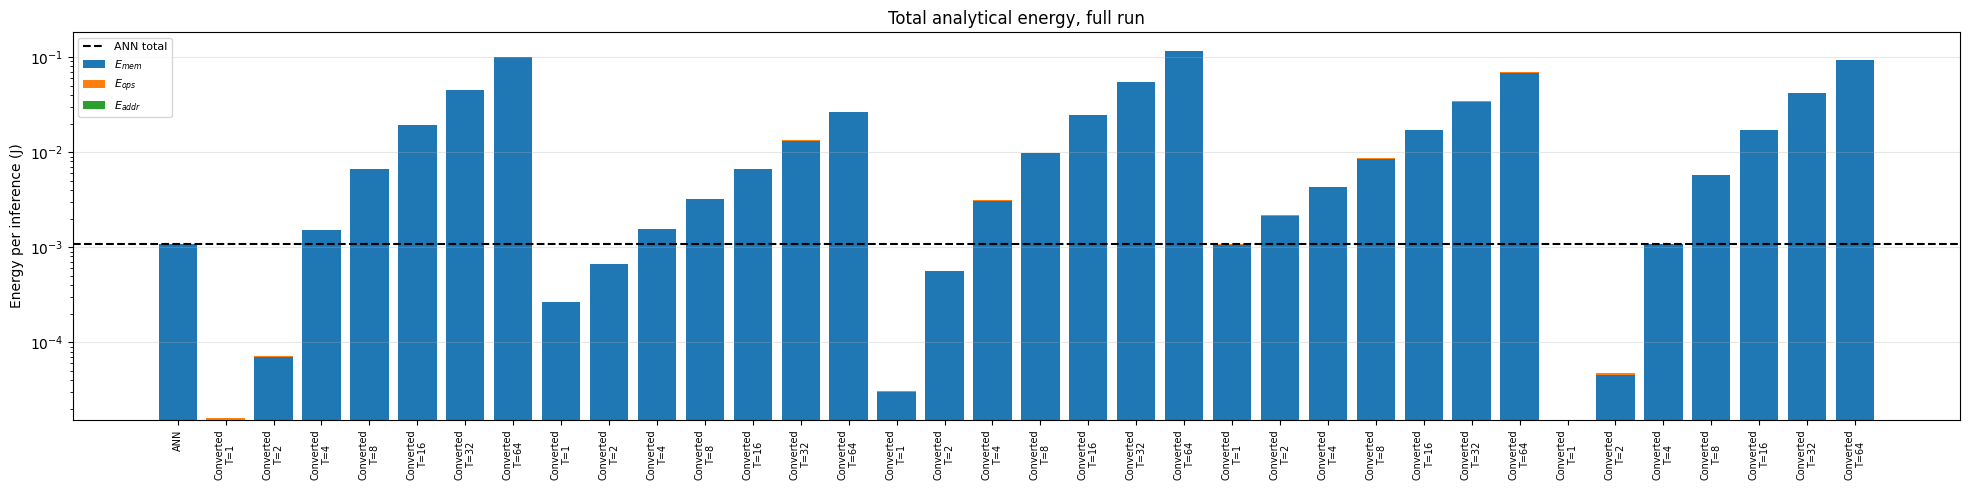

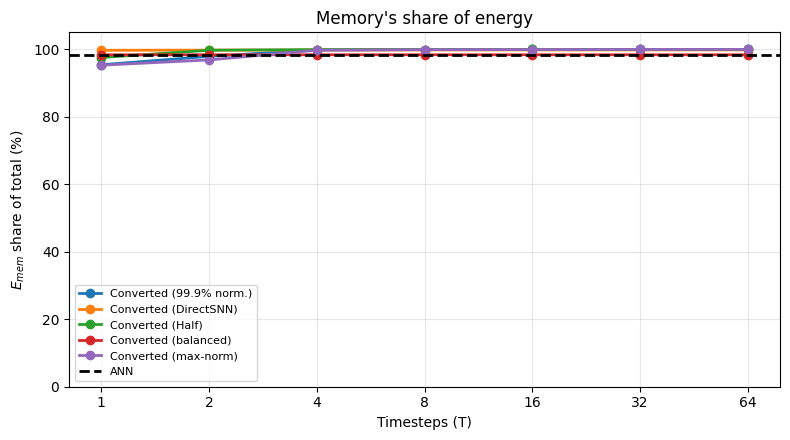

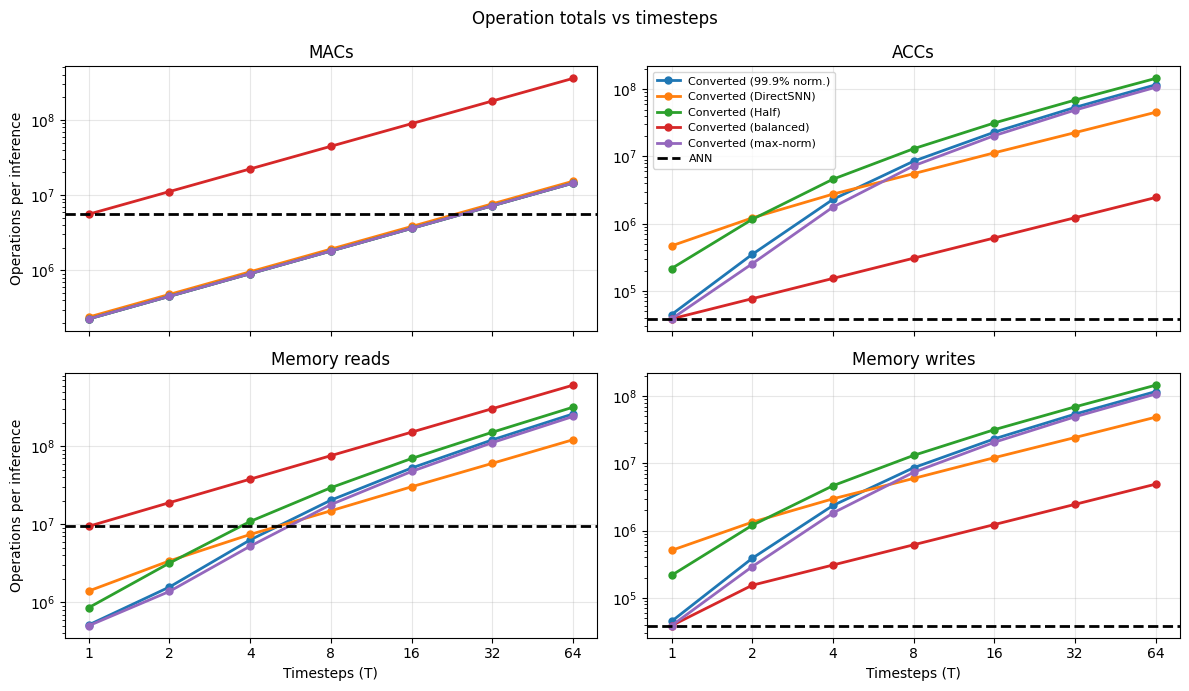

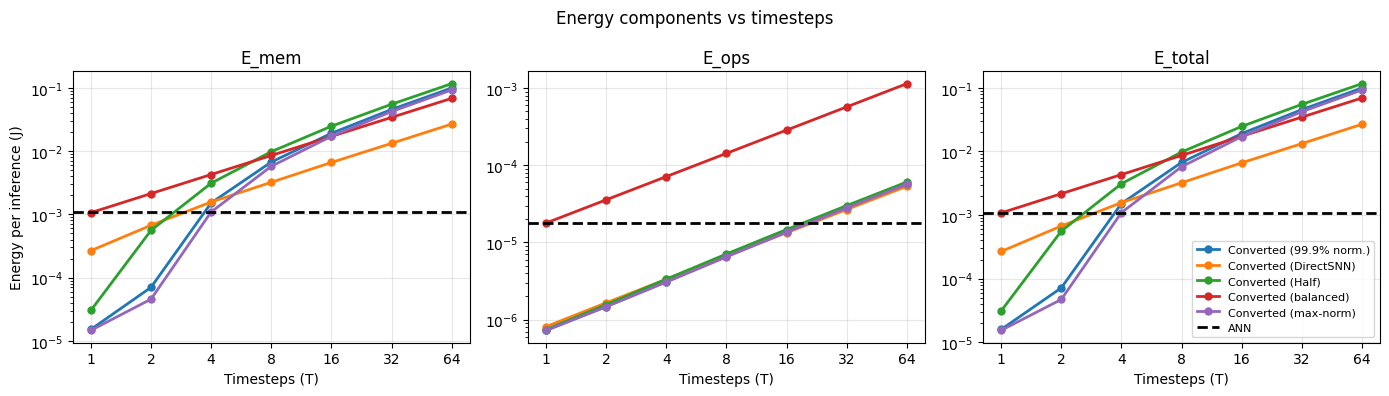

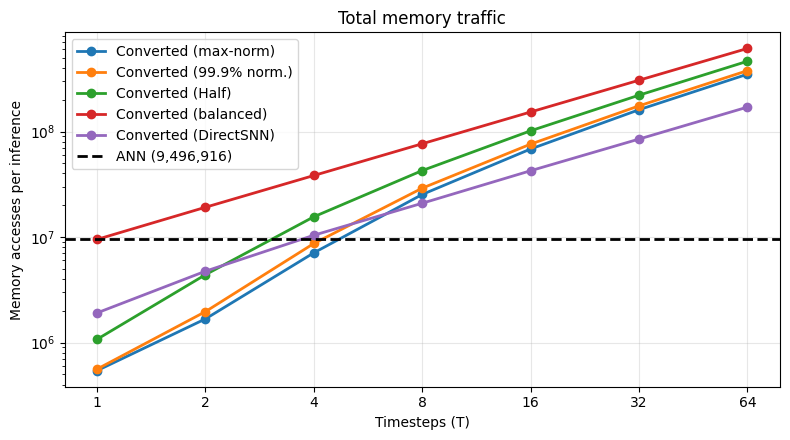

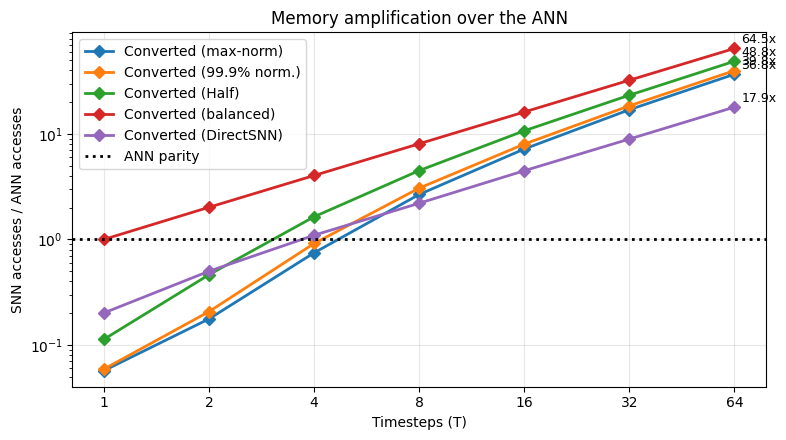

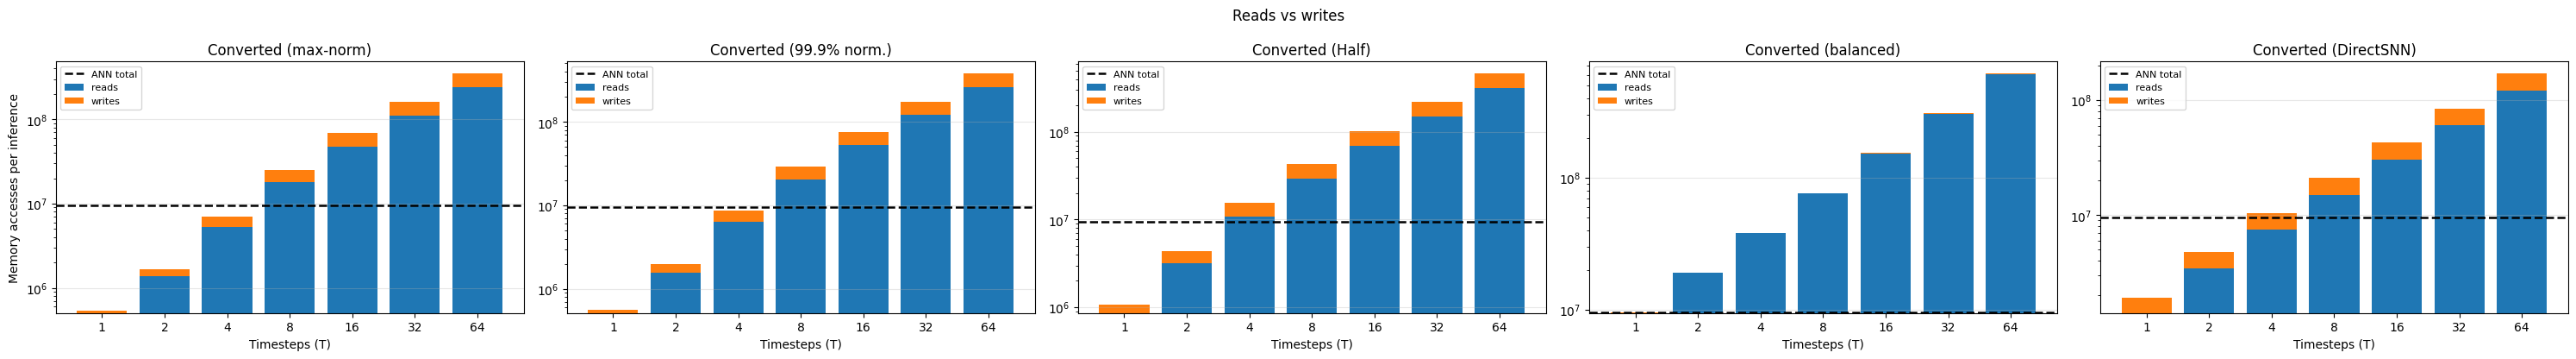

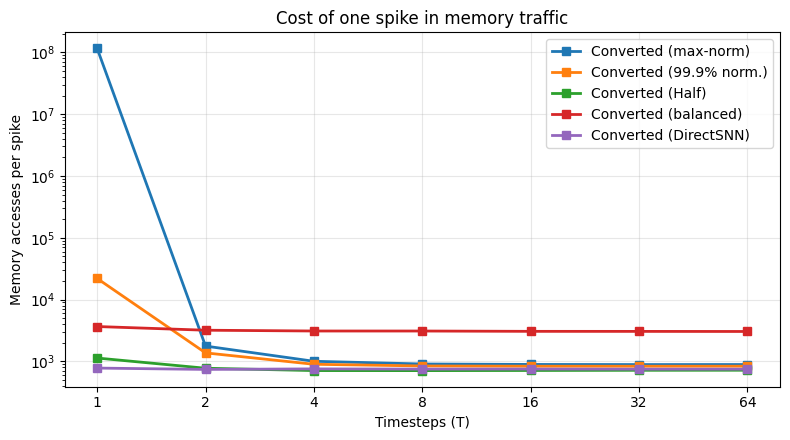

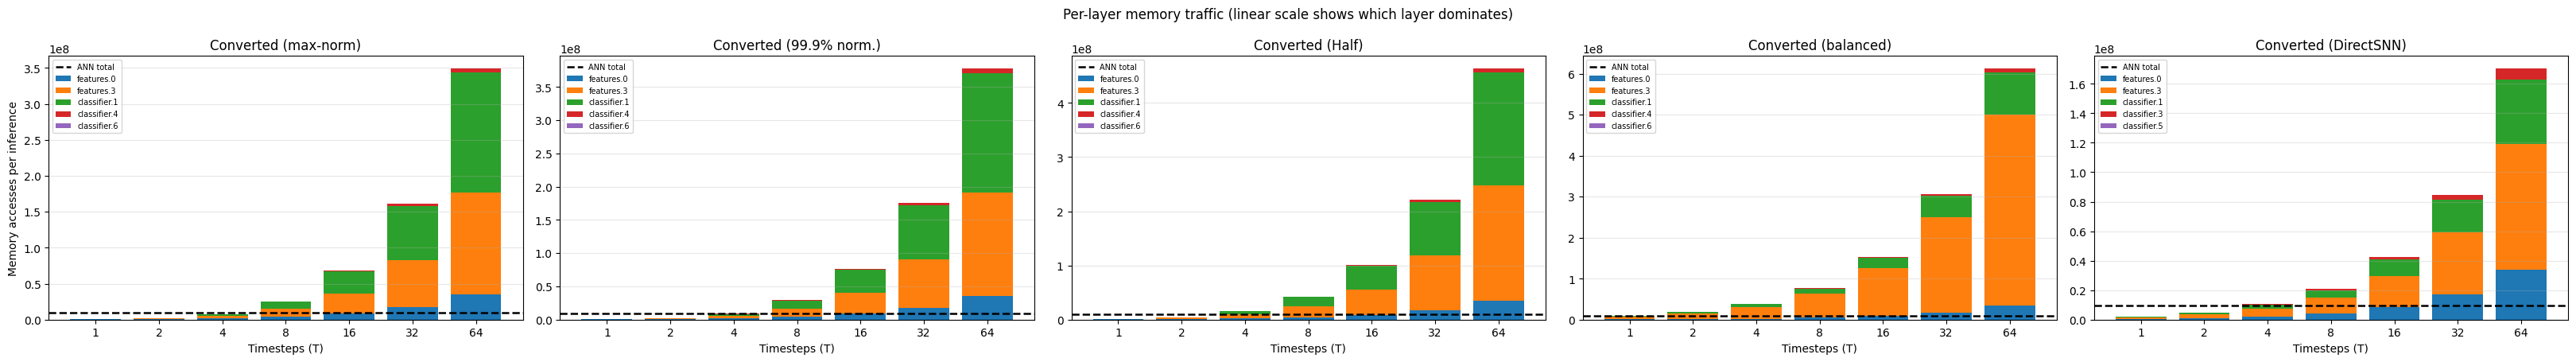

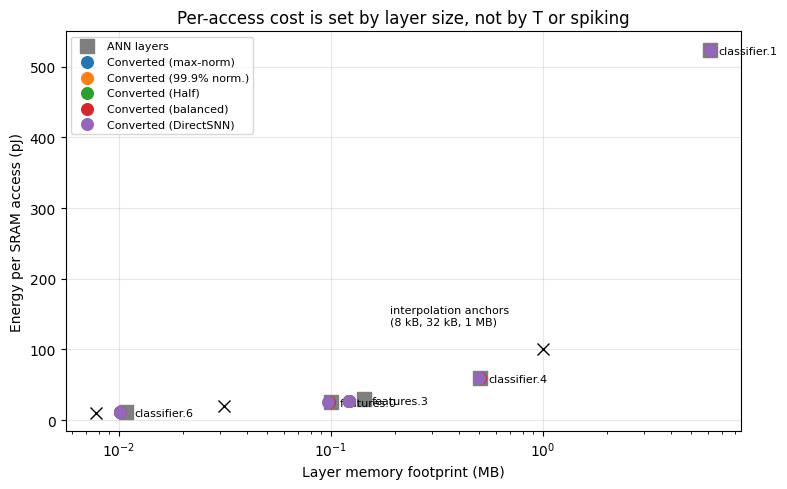

In [45]:
ann_bench_result, totals, snn_models_bench_results = Benchmark.run(ann, {
    "Converted (max-norm)": conv_snn_max,
    "Converted (99.9% norm.)": conv_snn_99,
    "Converted (Half)": conv_snn_half,
    "Converted (balanced)": conv_snn_balanced,
    "Converted (DirectSNN)": snn,
}, test_loader, cfg.device)

In [46]:
ann_bench_result

{'totals': {'E_mem': 0.0010766242669951278,
  'E_ops': 1.78525706e-05,
  'E_addr': 5.023400000000001e-09,
  'E_total': 0.0010944818609951276,
  'mac': 5577728.0,
  'acc': 38410.0,
  'rd': 9458506.0,
  'wr': 38410.0},
 'per_layer':           layer  kind      mac       rd     wr       mem_kB  pJ_per_access  \
 0    features.0  conv   225792   476672  25088   102.312500      25.670363   
 1    features.3  conv  3612672  7237888  12544   145.750000      29.173387   
 2  classifier.1    fc  1605632  1609280    512  6288.250000     524.536290   
 3  classifier.4    fc   131072   131840    256   516.000000      59.032258   
 4  classifier.6    fc     2560     2826     10    11.078125      11.282552   
 
           E_mem         E_ops       E_total  pct_of_total  
 0  1.288036e-05  7.250432e-07  1.360802e-05      1.243330  
 1  2.115197e-04  1.156180e-05  2.230834e-04     20.382558  
 2  8.443943e-04  5.138074e-06  8.495328e-04     77.619629  
 3  7.797925e-06  4.194560e-07  8.217458e-06      

In [47]:
snn_models_bench_results

{'Converted (max-norm)': (    T   total_spikes  total_neurons  spikes_per_neuron  \
  0   1       0.004687          38400       1.220703e-07   
  1   2     944.846484          38400       2.460538e-02   
  2   4    7043.035547          38400       1.834124e-01   
  3   8   27835.363672          38400       7.248793e-01   
  4  16   76342.626172          38400       1.988089e+00   
  5  32  180694.139062          38400       4.705577e+00   
  6  64  391663.664453          38400       1.019957e+01   
  
     spikes_per_neuron_per_step     snn_mac       snn_acc   snn_mem_ops  \
  0                1.220703e-07    225792.0  3.841270e+04  5.417341e+05   
  1                1.230269e-02    451584.0  2.539899e+05  1.675651e+06   
  2                4.585310e-02    903168.0  1.768329e+06  7.089393e+06   
  3                9.060991e-02   1806336.0  7.269449e+06  2.532639e+07   
  4                1.242556e-01   3612672.0  2.044256e+07  6.830633e+07   
  5                1.470493e-01   7225344.0

In [48]:
snn_models_bench_results

{'Converted (max-norm)': (    T   total_spikes  total_neurons  spikes_per_neuron  \
  0   1       0.004687          38400       1.220703e-07   
  1   2     944.846484          38400       2.460538e-02   
  2   4    7043.035547          38400       1.834124e-01   
  3   8   27835.363672          38400       7.248793e-01   
  4  16   76342.626172          38400       1.988089e+00   
  5  32  180694.139062          38400       4.705577e+00   
  6  64  391663.664453          38400       1.019957e+01   
  
     spikes_per_neuron_per_step     snn_mac       snn_acc   snn_mem_ops  \
  0                1.220703e-07    225792.0  3.841270e+04  5.417341e+05   
  1                1.230269e-02    451584.0  2.539899e+05  1.675651e+06   
  2                4.585310e-02    903168.0  1.768329e+06  7.089393e+06   
  3                9.060991e-02   1806336.0  7.269449e+06  2.532639e+07   
  4                1.242556e-01   3612672.0  2.044256e+07  6.830633e+07   
  5                1.470493e-01   7225344.0

In [49]:
from snn_bench.benchmark import BenchLevel 

In [50]:
Benchmark.query_levels(totals, BenchLevel.LEVEL_ONE)


,model,T,accuracy,spikes,neurons,spikes_per_neuron
0,ANN,NaN,0.8632,0.000000,0,NaN
1,Converted (max-norm),1.0,0.0946,0.004687,38400,1.220703e-07
2,Converted (max-norm),2.0,0.0946,944.846484,38400,2.460538e-02
3,Converted (max-norm),4.0,0.1156,7043.035547,38400,1.834124e-01
4,Converted (max-norm),8.0,0.7588,27835.363672,38400,7.248793e-01
5,Converted (max-norm),16.0,0.8322,76342.626172,38400,1.988089e+00
6,Converted (max-norm),32.0,0.8188,180694.139062,38400,4.705577e+00
7,Converted (max-norm),64.0,0.7836,391663.664453,38400,1.019957e+01
8,Converted (99.9% norm.),1.0,0.0946,25.466016,38400,6.631775e-04
9,Converted (99.9% norm.),2.0,0.0946,1427.029297,38400,3.716222e-02


In [51]:
Benchmark.query_levels(totals, BenchLevel.LEVEL_TWO, Ts=[8, 16, 32])


,model,T,accuracy,mac,acc,mem_reads,mem_writes,mem_accesses,accesses_per_mac,accesses_per_spike,mem_amplification,E_mem,E_ops,E_addr,E_total,pct_E_mem,mean_pJ_per_access,E_ratio_ann_over_model
0,ANN,NaN,0.8632,5577728.0,3.841000e+04,9.458506e+06,3.841000e+04,9.496916e+06,1.702650,NaN,1.000000,0.001077,0.000018,5.023400e-09,0.001094,98.368397,113.365672,1.000000
1,Converted (max-norm),8.0,0.7588,1806336.0,7.269449e+06,1.794949e+07,7.376899e+06,2.532639e+07,14.020864,909.863890,2.666802,0.005741,0.000007,7.542952e-07,0.005748,99.873674,226.680281,0.190402
2,Converted (max-norm),16.0,0.8322,3612672.0,2.044256e+07,4.766220e+07,2.064414e+07,6.830633e+07,18.907428,894.733885,7.192475,0.017158,0.000014,2.122703e-06,0.017174,99.908420,251.189270,0.063731
3,Converted (max-norm),32.0,0.8188,7225344.0,4.902339e+07,1.115485e+08,4.941323e+07,1.609617e+08,22.277382,890.796732,16.948844,0.042119,0.000028,5.092241e-06,0.042152,99.921437,261.669434,0.025965
4,Converted (99.9% norm.),8.0,0.7884,1806336.0,8.516972e+06,2.043991e+07,8.624422e+06,2.906433e+07,16.090213,845.703045,3.060397,0.006709,0.000007,8.855905e-07,0.006717,99.888078,230.841491,0.162948
5,Converted (99.9% norm.),16.0,0.8414,3612672.0,2.300562e+07,5.277729e+07,2.320720e+07,7.598449e+07,21.032768,837.832809,8.000965,0.019103,0.000014,2.392369e-06,0.019119,99.914987,251.401819,0.057246
6,Converted (99.9% norm.),32.0,0.8014,7225344.0,5.375657e+07,1.209926e+08,5.414641e+07,1.751390e+08,24.239542,837.406877,18.441674,0.045443,0.000028,5.591721e-06,0.045477,99.925042,259.466100,0.024067
7,Converted (Half),8.0,0.8386,1806336.0,1.305421e+07,2.950128e+07,1.316166e+07,4.266295e+07,23.618499,711.196170,4.492295,0.009778,0.000007,1.368046e-06,0.009786,99.913615,229.183926,0.111840
8,Converted (Half),16.0,0.7466,3612672.0,3.155758e+07,6.985399e+07,3.175915e+07,1.016131e+08,28.126868,714.763082,10.699594,0.024723,0.000015,3.303084e-06,0.024741,99.927167,243.301975,0.044238
9,Converted (Half),32.0,0.6110,7225344.0,6.906859e+07,1.515663e+08,6.945843e+07,2.210247e+08,30.590204,719.801233,23.273318,0.054982,0.000030,7.226400e-06,0.055019,99.932288,248.757818,0.019893


In [52]:
Benchmark.query_levels(totals, BenchLevel.LEVEL_THREE, models="Converted (max-norm)")


,model,T,accuracy,time_per_sample_ms,gpu_energy_per_sample_J,gpu_energy_marginal_per_sample_J,avg_gpu_power_W,power_spread_W,idle_power_W,gpu_peak_mem_MB,cpu_util_pct,energy_source
0,ANN,NaN,0.8632,0.176506,0.005609,0.000388,31.776968,0.231392,29.578816,110.753418,55.1,nvml_energy_counter
1,Converted (max-norm),1.0,0.0946,0.181980,0.006051,0.000496,33.199532,0.191542,30.479807,146.919434,56.8,nvml_energy_counter
2,Converted (max-norm),2.0,0.0946,0.189365,0.006837,0.001102,36.073383,0.294085,30.259939,153.419434,58.7,nvml_energy_counter
3,Converted (max-norm),4.0,0.1156,0.198576,0.011610,0.005367,58.464585,1.471813,31.439167,153.419434,61.8,nvml_energy_counter
4,Converted (max-norm),8.0,0.7588,0.218365,0.013928,0.007313,63.783057,0.443126,30.292189,153.419434,66.5,nvml_energy_counter
5,Converted (max-norm),16.0,0.8322,0.318099,0.020854,0.011488,65.513427,0.310848,29.416931,153.419434,53.1,nvml_energy_counter
6,Converted (max-norm),32.0,0.8188,0.611987,0.040625,0.022217,66.381433,0.351707,30.078499,153.419434,39.7,nvml_energy_counter
7,Converted (max-norm),64.0,0.7836,1.197267,0.080076,0.044052,66.823768,0.346934,30.030093,153.419434,32.7,nvml_energy_counter


In [53]:
Benchmark.query_levels(totals, [BenchLevel.LEVEL_ONE, BenchLevel.LEVEL_THREE])


,model,T,accuracy,spikes,neurons,spikes_per_neuron,time_per_sample_ms,gpu_energy_per_sample_J,gpu_energy_marginal_per_sample_J,avg_gpu_power_W,power_spread_W,idle_power_W,gpu_peak_mem_MB,cpu_util_pct,energy_source
0,ANN,NaN,0.8632,0.000000,0,NaN,0.176506,0.005609,0.000388,31.776968,0.231392,29.578816,110.753418,55.1,nvml_energy_counter
1,Converted (max-norm),1.0,0.0946,0.004687,38400,1.220703e-07,0.181980,0.006051,0.000496,33.199532,0.191542,30.479807,146.919434,56.8,nvml_energy_counter
2,Converted (max-norm),2.0,0.0946,944.846484,38400,2.460538e-02,0.189365,0.006837,0.001102,36.073383,0.294085,30.259939,153.419434,58.7,nvml_energy_counter
3,Converted (max-norm),4.0,0.1156,7043.035547,38400,1.834124e-01,0.198576,0.011610,0.005367,58.464585,1.471813,31.439167,153.419434,61.8,nvml_energy_counter
4,Converted (max-norm),8.0,0.7588,27835.363672,38400,7.248793e-01,0.218365,0.013928,0.007313,63.783057,0.443126,30.292189,153.419434,66.5,nvml_energy_counter
5,Converted (max-norm),16.0,0.8322,76342.626172,38400,1.988089e+00,0.318099,0.020854,0.011488,65.513427,0.310848,29.416931,153.419434,53.1,nvml_energy_counter
6,Converted (max-norm),32.0,0.8188,180694.139062,38400,4.705577e+00,0.611987,0.040625,0.022217,66.381433,0.351707,30.078499,153.419434,39.7,nvml_energy_counter
7,Converted (max-norm),64.0,0.7836,391663.664453,38400,1.019957e+01,1.197267,0.080076,0.044052,66.823768,0.346934,30.030093,153.419434,32.7,nvml_energy_counter
8,Converted (99.9% norm.),1.0,0.0946,25.466016,38400,6.631775e-04,0.181068,0.005926,0.000478,32.727476,0.433528,30.089259,146.772949,56.8,nvml_energy_counter
9,Converted (99.9% norm.),2.0,0.0946,1427.029297,38400,3.716222e-02,0.186822,0.006724,0.001031,35.981863,0.548347,30.463325,153.272949,58.6,nvml_energy_counter


In [54]:
Benchmark.query_levels(totals, BenchLevel.LEVEL_ALL, include_ann=False)

,model,T,accuracy,spikes,neurons,spikes_per_neuron,mac,acc,mem_reads,mem_writes,...,E_ratio_ann_over_model,time_per_sample_ms,gpu_energy_per_sample_J,gpu_energy_marginal_per_sample_J,avg_gpu_power_W,power_spread_W,idle_power_W,gpu_peak_mem_MB,cpu_util_pct,energy_source
0,Converted (max-norm),1.0,0.0946,0.004687,38400,1.220703e-07,225792.0,3.841270e+04,5.033214e+05,3.841270e+04,...,71.144840,0.181980,0.006051,0.000496,33.199532,0.191542,30.479807,146.919434,56.8,nvml_energy_counter
1,Converted (max-norm),2.0,0.0946,944.846484,38400,2.460538e-02,451584.0,2.539899e+05,1.384807e+06,2.908439e+05,...,23.233364,0.189365,0.006837,0.001102,36.073383,0.294085,30.259939,153.419434,58.7,nvml_energy_counter
2,Converted (max-norm),4.0,0.1156,7043.035547,38400,1.834124e-01,903168.0,1.768329e+06,5.260678e+06,1.828715e+06,...,1.001676,0.198576,0.011610,0.005367,58.464585,1.471813,31.439167,153.419434,61.8,nvml_energy_counter
3,Converted (max-norm),8.0,0.7588,27835.363672,38400,7.248793e-01,1806336.0,7.269449e+06,1.794949e+07,7.376899e+06,...,0.190402,0.218365,0.013928,0.007313,63.783057,0.443126,30.292189,153.419434,66.5,nvml_energy_counter
4,Converted (max-norm),16.0,0.8322,76342.626172,38400,1.988089e+00,3612672.0,2.044256e+07,4.766220e+07,2.064414e+07,...,0.063731,0.318099,0.020854,0.011488,65.513427,0.310848,29.416931,153.419434,53.1,nvml_energy_counter
5,Converted (max-norm),32.0,0.8188,180694.139062,38400,4.705577e+00,7225344.0,4.902339e+07,1.115485e+08,4.941323e+07,...,0.025965,0.611987,0.040625,0.022217,66.381433,0.351707,30.078499,153.419434,39.7,nvml_energy_counter
6,Converted (max-norm),64.0,0.7836,391663.664453,38400,1.019957e+01,14450688.0,1.071972e+08,2.413412e+08,1.079635e+08,...,0.011800,1.197267,0.080076,0.044052,66.823768,0.346934,30.030093,153.419434,32.7,nvml_energy_counter
7,Converted (99.9% norm.),1.0,0.0946,25.466016,38400,6.631775e-04,225792.0,4.453518e+04,5.155770e+05,4.453518e+04,...,68.880718,0.181068,0.005926,0.000478,32.727476,0.433528,30.089259,146.772949,56.8,nvml_energy_counter
8,Converted (99.9% norm.),2.0,0.0946,1427.029297,38400,3.716222e-02,451584.0,3.501928e+05,1.577290e+06,3.870468e+05,...,15.291646,0.186822,0.006724,0.001031,35.981863,0.548347,30.463325,153.272949,58.6,nvml_energy_counter
9,Converted (99.9% norm.),4.0,0.3920,9652.629297,38400,2.513706e-01,903168.0,2.302659e+06,6.327734e+06,2.363045e+06,...,0.721610,0.197761,0.011650,0.005500,58.962106,2.614713,31.124995,153.272949,61.9,nvml_energy_counter


                  model    T  accuracy  baseline_accuracy  retention  retention_pct   delta_pp  delta_rel_pct          label
   Converted (max-norm)  1.0    0.0946             0.8632   0.109592      10.959221 -76.860001     -89.040779 0.11x (-89.0%)
   Converted (max-norm)  2.0    0.0946             0.8632   0.109592      10.959221 -76.860001     -89.040779 0.11x (-89.0%)
   Converted (max-norm)  4.0    0.1156             0.8632   0.133920      13.392030 -74.760001     -86.607970 0.13x (-86.6%)
   Converted (max-norm)  8.0    0.7588             0.8632   0.879055      87.905467 -10.440001     -12.094533 0.88x (-12.1%)
   Converted (max-norm) 16.0    0.8322             0.8632   0.964087      96.408711  -3.100001      -3.591289  0.96x (-3.6%)
   Converted (max-norm) 32.0    0.8188             0.8632   0.948563      94.856347  -4.440001      -5.143653  0.95x (-5.1%)
   Converted (max-norm) 64.0    0.7836             0.8632   0.907785      90.778498  -7.960001      -9.221502  0.91x (-9.2%)


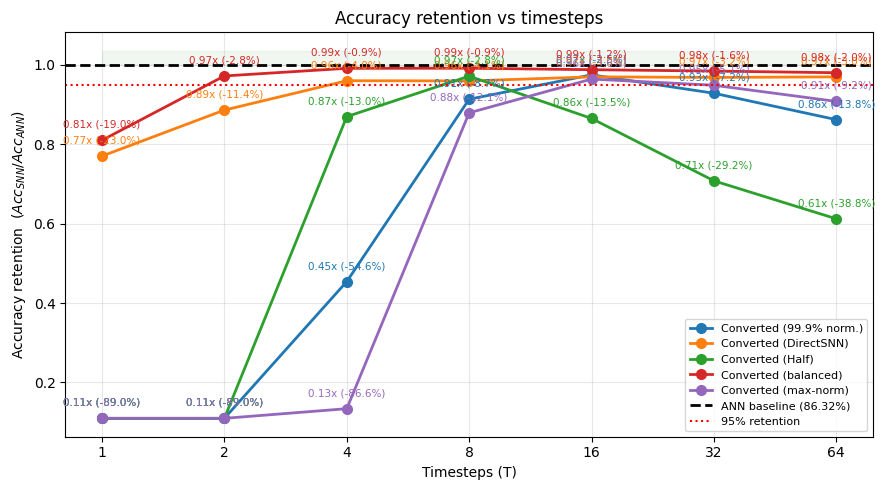

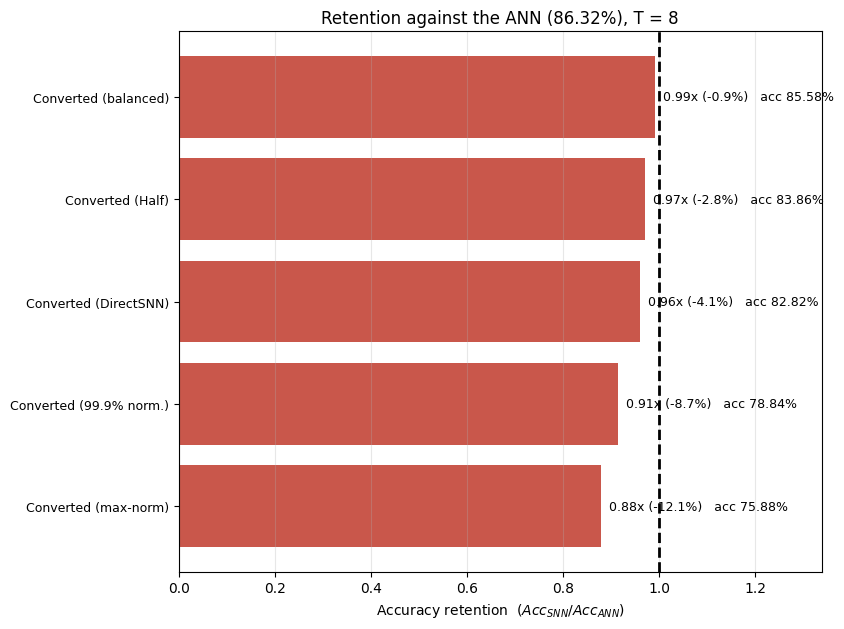

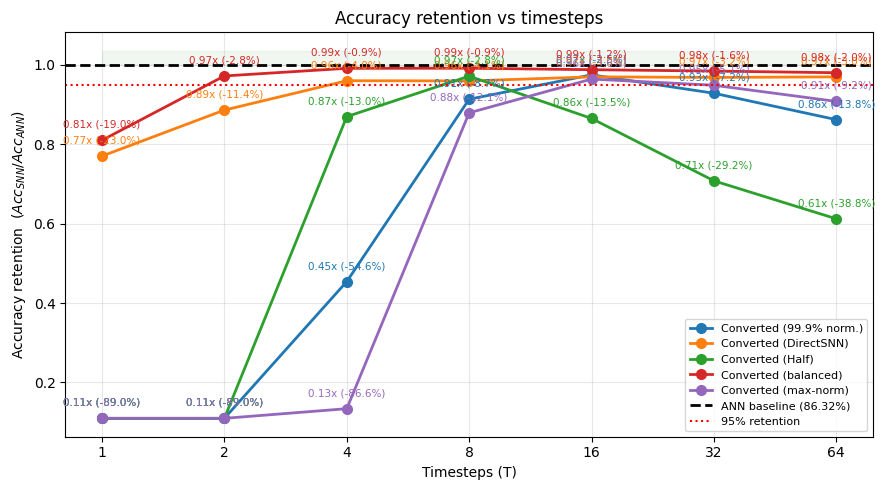

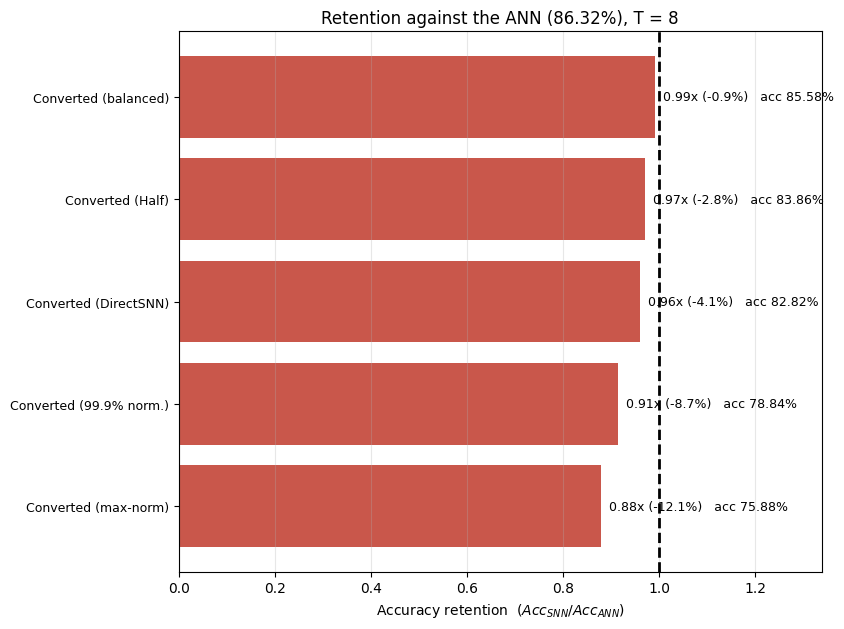

In [55]:
ret = Benchmark.accuracy_retention(
    ann_results['ANN'].accuracy,  # baseline accuracy as a float
    {
        "Converted (max-norm)": conv_snn_max,
        "Converted (99.9% norm.)": conv_snn_99,
        "Converted (Half)": conv_snn_half,
        "Converted (balanced)": conv_snn_balanced,
        "Converted (DirectSNN)": snn,
    },    # the model itself
    loader=test_loader, device=cfg.device,
    Ts=[1, 2, 4, 8, 16, 32, 64],
)

print(ret.to_string(index=False))
print(Benchmark.best_retention(ret).to_string(index=False))

Benchmark.plot_accuracy_retention(ret)                 # picks the best T for the bar chart
Benchmark.plot_accuracy_retention(ret, at_T=8)         # or force one

In [56]:
snn_models_bench_results['Converted (max-norm)'][0]

,T,total_spikes,total_neurons,spikes_per_neuron,spikes_per_neuron_per_step,snn_mac,snn_acc,snn_mem_ops,ann_mac,ann_mem_ops,...,gpu_energy_per_sample_J,gpu_energy_marginal_per_sample_J,avg_gpu_power_W,power_spread_W,energy_source,cpu_util_pct,gpu_peak_mem_MB,accuracy,acc_per_joule_raw,acc_per_joule
0,1,0.004687,38400,1.220703e-07,1.220703e-07,225792.0,3.841270e+04,5.417341e+05,5577728.0,9496916.0,...,0.006051,0.000496,33.199532,0.191542,nvml_energy_counter,56.8,146.919434,0.0946,6149.304142,NaN
1,2,944.846484,38400,2.460538e-02,1.230269e-02,451584.0,2.539899e+05,1.675651e+06,5577728.0,9496916.0,...,0.006837,0.001102,36.073383,0.294085,nvml_energy_counter,58.7,153.419434,0.0946,2008.143117,NaN
2,4,7043.035547,38400,1.834124e-01,4.585310e-02,903168.0,1.768329e+06,7.089393e+06,5577728.0,9496916.0,...,0.011610,0.005367,58.464585,1.471813,nvml_energy_counter,61.8,153.419434,0.1156,105.797757,NaN
3,8,27835.363672,38400,7.248793e-01,9.060991e-02,1806336.0,7.269449e+06,2.532639e+07,5577728.0,9496916.0,...,0.013928,0.007313,63.783057,0.443126,nvml_energy_counter,66.5,153.419434,0.7588,132.005273,114.608690
4,16,76342.626172,38400,1.988089e+00,1.242556e-01,3612672.0,2.044256e+07,6.830633e+07,5577728.0,9496916.0,...,0.020854,0.011488,65.513427,0.310848,nvml_energy_counter,53.1,153.419434,0.8322,48.458251,42.635342
5,32,180694.139062,38400,4.705577e+00,1.470493e-01,7225344.0,4.902339e+07,1.609617e+08,5577728.0,9496916.0,...,0.040625,0.022217,66.381433,0.351707,nvml_energy_counter,39.7,153.419434,0.8188,19.424991,17.052618
6,64,391663.664453,38400,1.019957e+01,1.593684e-01,14450688.0,1.071972e+08,3.493048e+08,5577728.0,9496916.0,...,0.080076,0.044052,66.823768,0.346934,nvml_energy_counter,32.7,153.419434,0.7836,8.448432,7.370276


In [57]:
snn_eff = Benchmark.calculate_energy_efficiency_from_summary(snn_models_bench_results['Converted (max-norm)'][0], n_classes=NUM_CLASSES, min_accuracy=0.5)

In [58]:
snn_eff

,T,accuracy,E_joules,eff_raw,eff_above_chance
0,1,0.0946,0.000015,6149.304142,NaN
1,2,0.0946,0.000047,2008.143117,NaN
2,4,0.1156,0.001093,105.797757,NaN
3,8,0.7588,0.005748,132.005273,114.608690
4,16,0.8322,0.017174,48.458251,42.635342
5,32,0.8188,0.042152,19.424991,17.052618
6,64,0.7836,0.092751,8.448432,7.370276


In [59]:
ann_bench_result

{'totals': {'E_mem': 0.0010766242669951278,
  'E_ops': 1.78525706e-05,
  'E_addr': 5.023400000000001e-09,
  'E_total': 0.0010944818609951276,
  'mac': 5577728.0,
  'acc': 38410.0,
  'rd': 9458506.0,
  'wr': 38410.0},
 'per_layer':           layer  kind      mac       rd     wr       mem_kB  pJ_per_access  \
 0    features.0  conv   225792   476672  25088   102.312500      25.670363   
 1    features.3  conv  3612672  7237888  12544   145.750000      29.173387   
 2  classifier.1    fc  1605632  1609280    512  6288.250000     524.536290   
 3  classifier.4    fc   131072   131840    256   516.000000      59.032258   
 4  classifier.6    fc     2560     2826     10    11.078125      11.282552   
 
           E_mem         E_ops       E_total  pct_of_total  
 0  1.288036e-05  7.250432e-07  1.360802e-05      1.243330  
 1  2.115197e-04  1.156180e-05  2.230834e-04     20.382558  
 2  8.443943e-04  5.138074e-06  8.495328e-04     77.619629  
 3  7.797925e-06  4.194560e-07  8.217458e-06      

In [60]:
ann_eff = Benchmark.calculate_energy_efficiency(ann_bench_result['accuracy'], ann_bench_result['totals']['E_total'])

In [61]:
ann_eff

788.683696607963

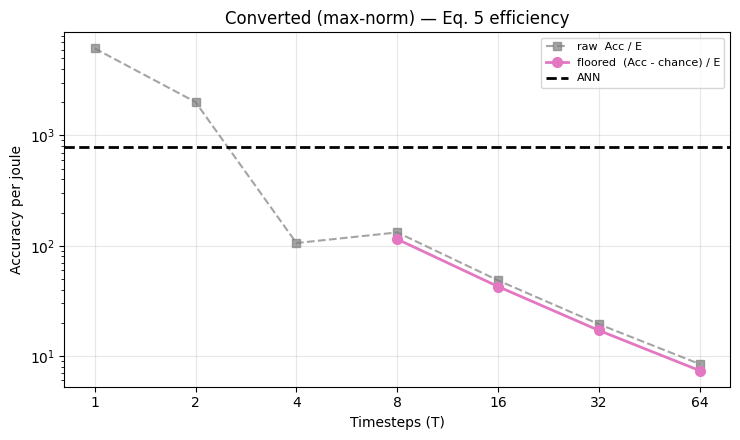

In [63]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (max-norm)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (max-norm) — ")

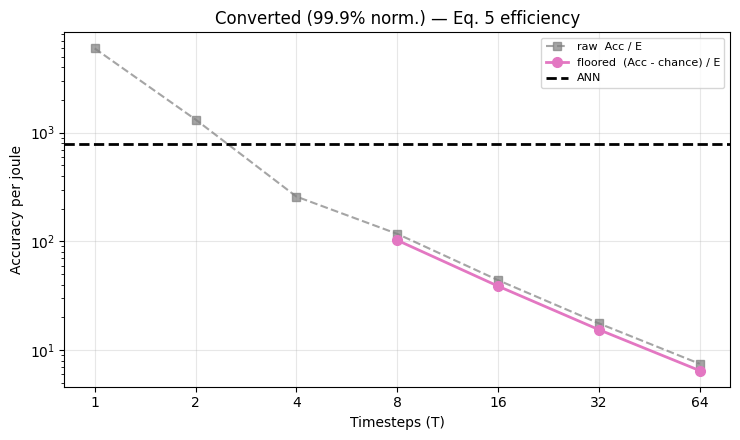

In [64]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (99.9% norm.)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (99.9% norm.) — ")

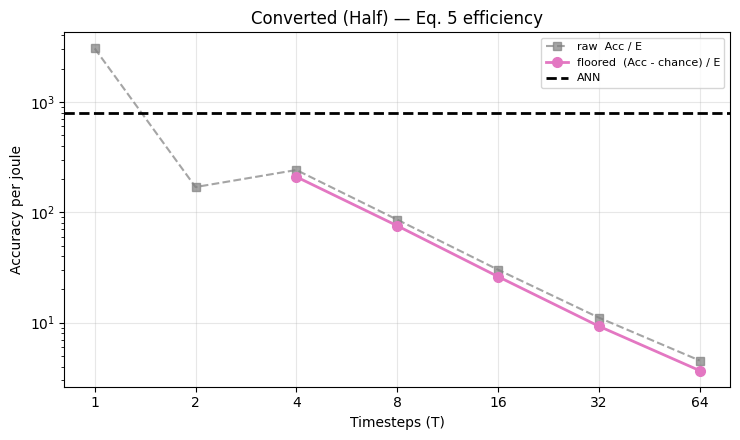

In [65]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (Half)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (Half) — ")

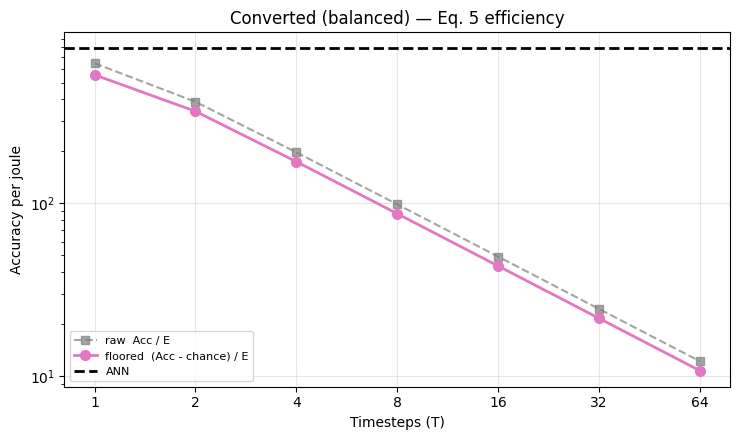

In [66]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (balanced)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (balanced) — ")

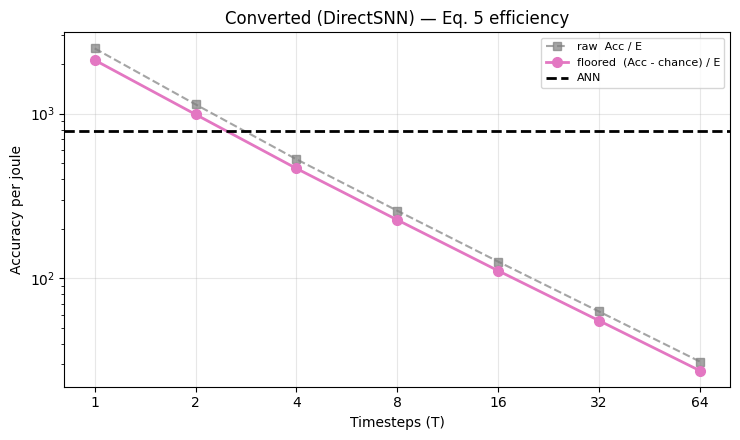

In [67]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (DirectSNN)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (DirectSNN) — ")

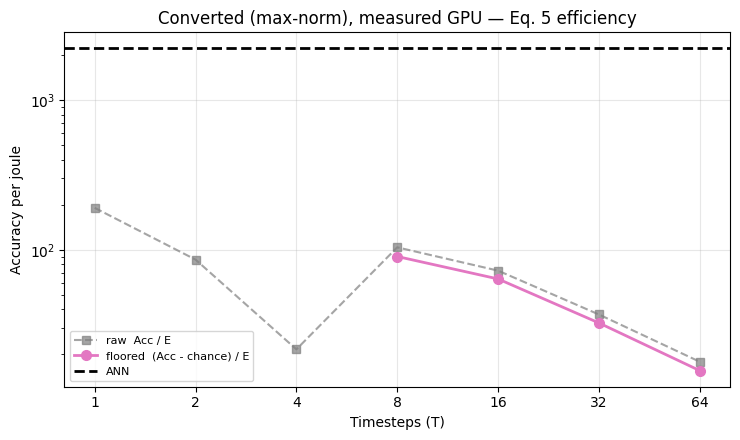

In [68]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (max-norm)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (max-norm), measured GPU — ")

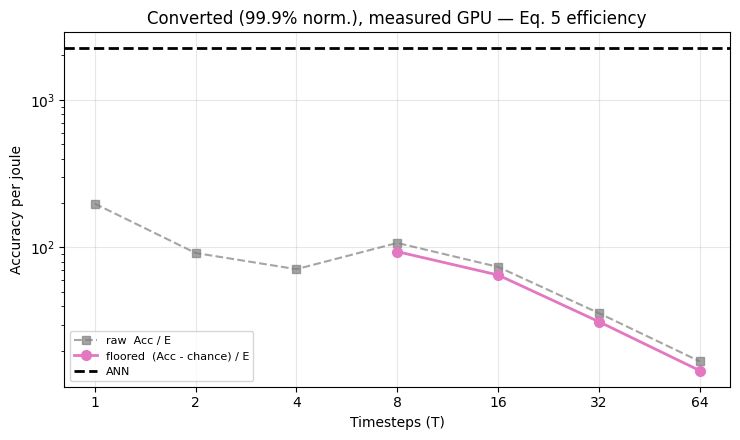

In [69]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (99.9% norm.)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (99.9% norm.), measured GPU — ")

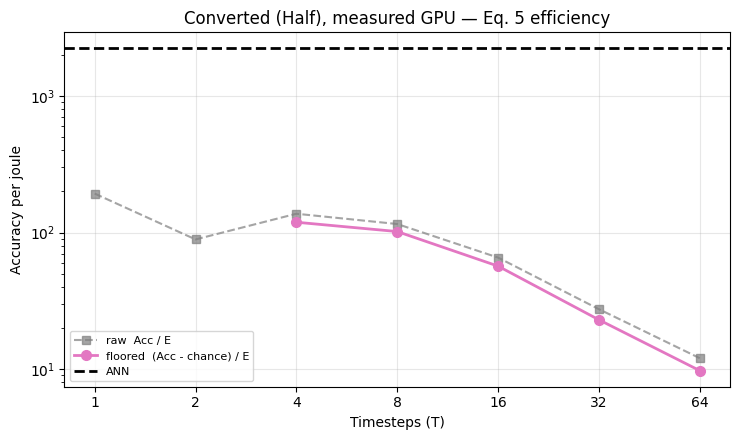

In [70]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (Half)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (Half), measured GPU — ")

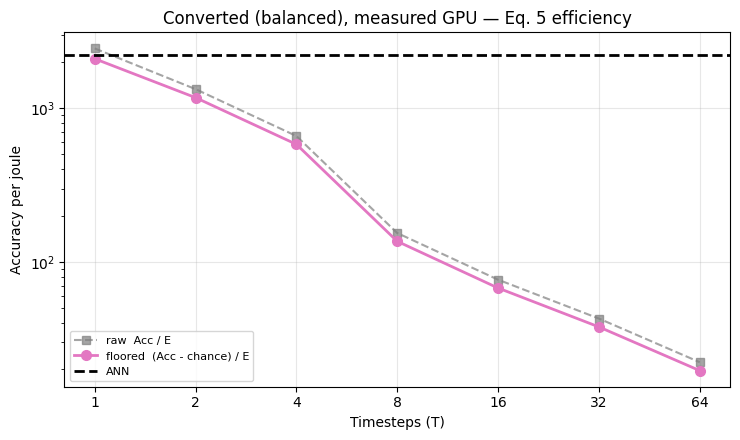

In [71]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (balanced)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (balanced), measured GPU — ")

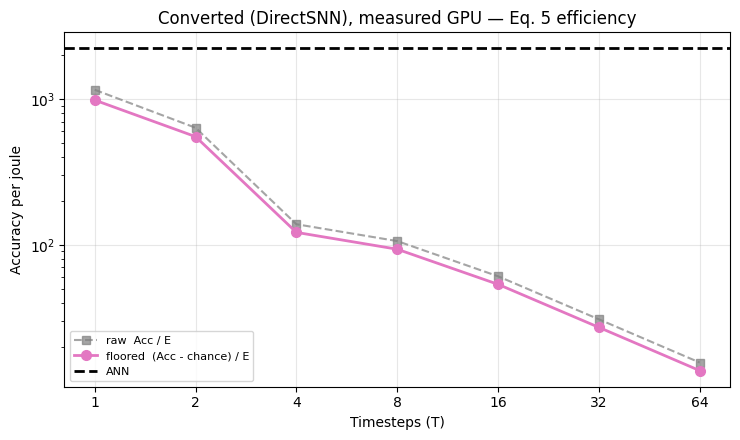

In [72]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (DirectSNN)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (DirectSNN), measured GPU — ")

In [73]:
from pathlib import Path
filepath_l1 = Path("results/level_one.csv")
filepath_l2 = Path("results/level_two.csv")
filepath_l3 = Path("results/level_thee.csv")
filepath_l1.parent.mkdir(parents=True, exist_ok=True)
filepath_l2.parent.mkdir(parents=True, exist_ok=True)
filepath_l3.parent.mkdir(parents=True, exist_ok=True)

In [74]:
l1 = Benchmark.query_levels(totals, BenchLevel.LEVEL_ONE)
l1.to_csv(filepath_l1)

In [75]:
l2 = Benchmark.query_levels(totals, BenchLevel.LEVEL_TWO)
l2.to_csv(filepath_l2)

In [76]:
l3 = Benchmark.query_levels(totals, BenchLevel.LEVEL_THREE)
l3.to_csv(filepath_l3)